# Visualisasi Hasil Seleksi SLM (Bab 4.1)
Notebook ini menghasilkan seluruh grafik untuk subbab 4.1 (Hasil Seleksi Small Language Model).
Pastikan empat berkas CSV berada pada direktori yang sama: `ranking_summary.csv`, `ranking_final_komprehensif.csv`, `posthoc_mannwhitney.csv`, `breakdown_mmlu_subject_all.csv`.

## Setup, pemuatan data, dan konfigurasi global

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({"font.family": "serif", "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.dpi": 150})

s = pd.read_csv("ranking_summary.csv")
k = pd.read_csv("ranking_final_komprehensif.csv")
mw = pd.read_csv("posthoc_mannwhitney.csv")
cr = pd.read_csv("breakdown_mmlu_subject_all.csv")

PARAMS = {"Llama-3.1-8B":8.0,"Llama3.2-3B":3.2,"Gemma-2-2B":2.6,"Mistral-7B":7.2,
          "Qwen2.5-7B":7.6,"Phi-3.5-mini":3.8,"Llama3.2-1B":1.2,"Qwen2.5-3B":3.1,
          "Qwen2.5-1.5B":1.5,"Qwen2.5-0.5B":0.5,"SmolLM2-360M":0.36,"SmolLM2-135M":0.135}
ELIG = {"Llama-3.1-8B":False,"Llama3.2-3B":True,"Gemma-2-2B":True,"Mistral-7B":True,
        "Qwen2.5-7B":True,"Phi-3.5-mini":True,"Llama3.2-1B":True,"Qwen2.5-3B":True,
        "Qwen2.5-1.5B":True,"Qwen2.5-0.5B":True,"SmolLM2-360M":True,"SmolLM2-135M":True}
C_MMLU, C_CAR, C_ELIG, C_DQ, C_TOP = "#2c6fbb", "#e08a1e", "#3a7d44", "#b3b3b3", "#c0392b"

## Fungsi bantu (matriks MMLU, IndoCareer, rumpun)

In [2]:
RUMPUN = {
    "Bahasa Bali":"Bahasa Daerah","Bahasa Banjar":"Bahasa Daerah","Bahasa Dayak Ngaju":"Bahasa Daerah",
    "Bahasa Jawa":"Bahasa Daerah","Bahasa Lampung":"Bahasa Daerah","Bahasa Madura":"Bahasa Daerah",
    "Bahasa Makassar":"Bahasa Daerah","Bahasa Sunda":"Bahasa Daerah",
    "Bahasa Indonesia":"Bahasa Nasional",
    "Biologi":"Sains","Fisika":"Sains","Kimia":"Sains","IPA":"Sains",
    "Ekonomi":"Sosial","Geografi":"Sosial","IPS":"Sosial","PPKN":"Sosial","Sejarah":"Sosial","Sosiologi":"Sosial",
    "Agama Hindu":"Agama","Agama Islam":"Agama","Agama Kristen":"Agama",
    "Budaya Alam Minangkabau":"Seni-Budaya-Olahraga","Kesenian":"Seni-Budaya-Olahraga","Penjaskes":"Seni-Budaya-Olahraga",
}
RUMPUN_ORDER = ["Bahasa Nasional","Bahasa Daerah","Sains","Sosial","Agama","Seni-Budaya-Olahraga"]

def _mmlu_matrix():
    mc = [c for c in k.columns if c.startswith("mmlu_")]
    m = k.set_index("model")[mc].copy(); m.columns = [c.replace("mmlu_","") for c in mc]
    return m.loc[s.model_name]

def _career_matrix():
    cats = [c for c in cr.columns if c not in ("rank","model","indocareer_acc")]
    return cr.set_index("model")[cats].loc[s.model_name]

def _rumpun_matrix():
    m = _mmlu_matrix().copy()
    g = m.T.groupby(RUMPUN).mean().T
    return g[RUMPUN_ORDER]

## Fungsi pembuat grafik (satu sel per grafik)

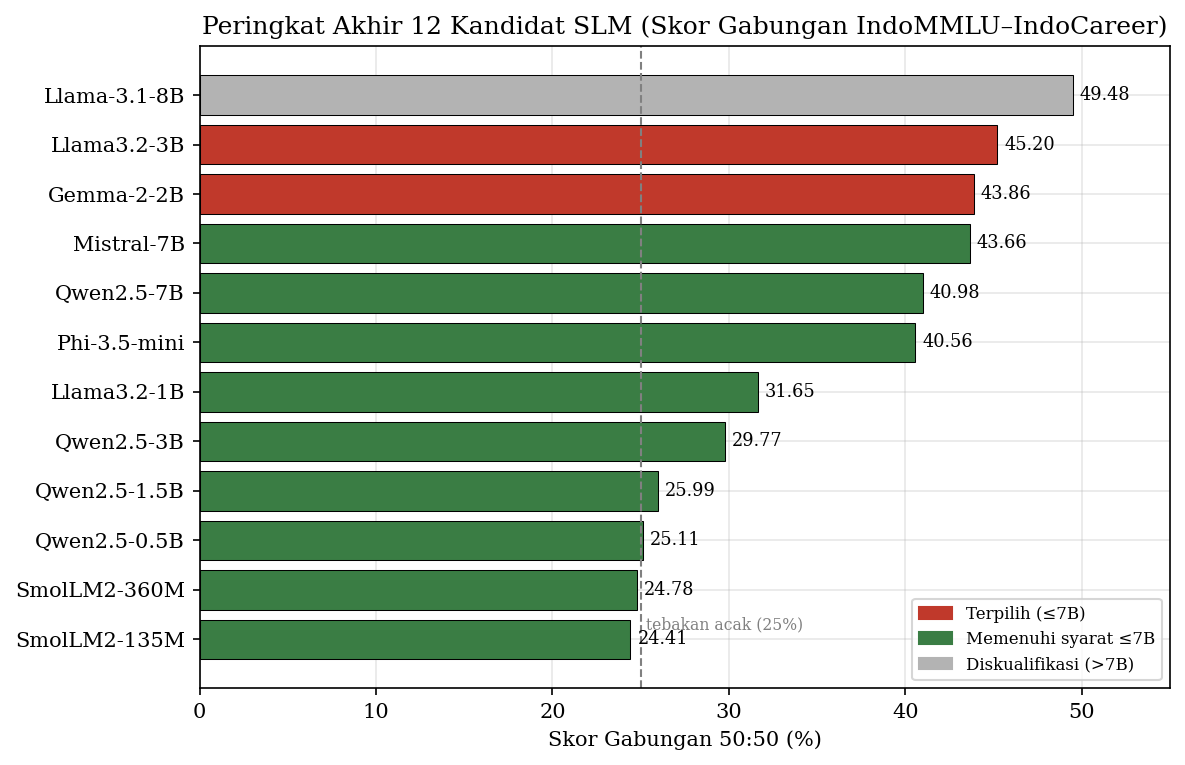

In [3]:
def fig1_final_ranking():
    d = s.sort_values("final_score_50_50")
    colors = [C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else
              (C_DQ if not ELIG[m] else C_ELIG) for m in d.model_name]
    fig, ax = plt.subplots(figsize=(8,5.2))
    ax.barh(d.model_name, d.final_score_50_50, color=colors, edgecolor="black", linewidth=.5)
    for y,(v,m) in enumerate(zip(d.final_score_50_50, d.model_name)):
        ax.text(v+.4, y, f"{v:.2f}", va="center", fontsize=8.5)
    ax.axvline(25, ls="--", color="gray", lw=1); ax.text(25.3, .2, "tebakan acak (25%)", fontsize=7.5, color="gray")
    ax.set_xlabel("Skor Gabungan 50:50 (%)"); ax.set_xlim(0, 55)
    ax.set_title("Peringkat Akhir 12 Kandidat SLM (Skor Gabungan IndoMMLU–IndoCareer)")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=C_TOP,label="Terpilih (≤7B)"),
                       Patch(color=C_ELIG,label="Memenuhi syarat ≤7B"),
                       Patch(color=C_DQ,label="Diskualifikasi (>7B)")], fontsize=8, loc="lower right")
    plt.tight_layout(); plt.savefig("fig1_ranking_akhir.png", bbox_inches="tight"); plt.show()

fig1_final_ranking()

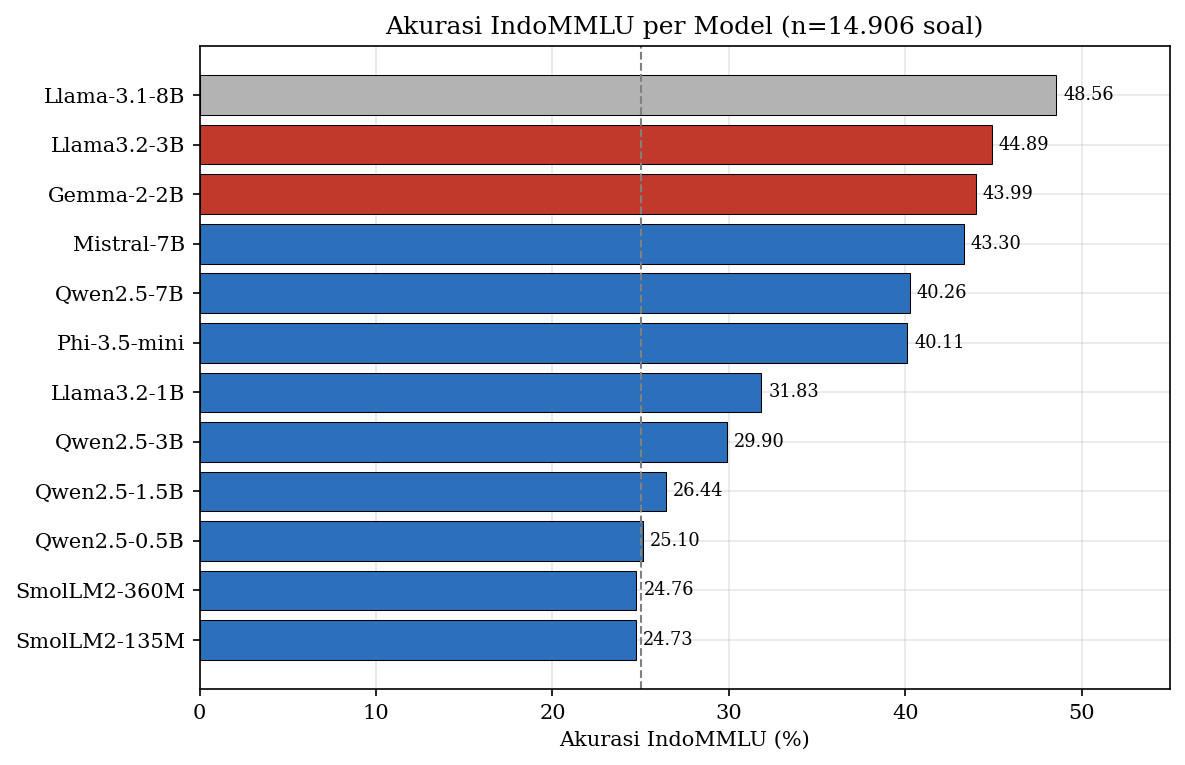

In [4]:
def fig2_indommlu():
    d = s.sort_values("indommlu_acc", ascending=True)
    colors = [C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else
              (C_DQ if not ELIG[m] else C_MMLU) for m in d.model_name]
    fig, ax = plt.subplots(figsize=(8,5.2))
    ax.barh(d.model_name, d.indommlu_acc, color=colors, edgecolor="black", linewidth=.5)
    for y,v in enumerate(d.indommlu_acc): ax.text(v+.4, y, f"{v:.2f}", va="center", fontsize=8.5)
    ax.axvline(25, ls="--", color="gray", lw=1)
    ax.set_xlabel("Akurasi IndoMMLU (%)"); ax.set_xlim(0,55)
    ax.set_title("Akurasi IndoMMLU per Model (n=14.906 soal)")
    plt.tight_layout(); plt.savefig("fig2_indommlu.png", bbox_inches="tight"); plt.show()

fig2_indommlu()

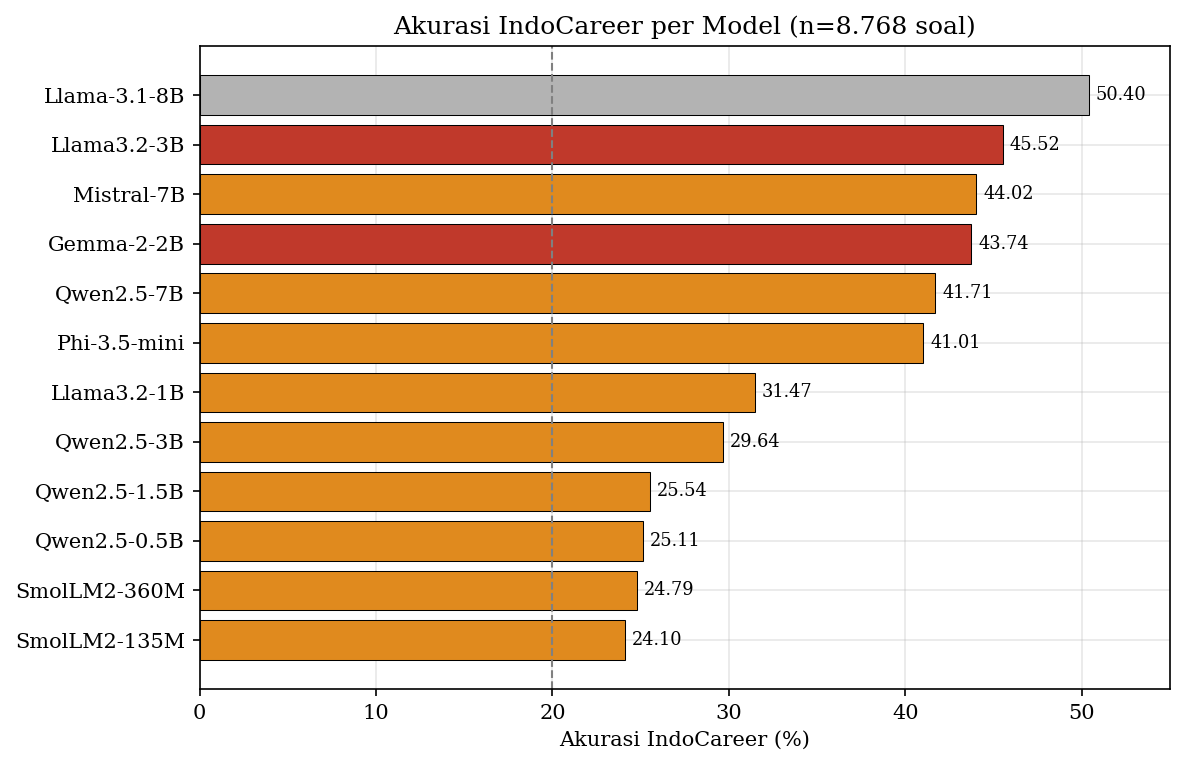

In [5]:
def fig3_indocareer():
    d = s.sort_values("indocareer_acc", ascending=True)
    colors = [C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else
              (C_DQ if not ELIG[m] else C_CAR) for m in d.model_name]
    fig, ax = plt.subplots(figsize=(8,5.2))
    ax.barh(d.model_name, d.indocareer_acc, color=colors, edgecolor="black", linewidth=.5)
    for y,v in enumerate(d.indocareer_acc): ax.text(v+.4, y, f"{v:.2f}", va="center", fontsize=8.5)
    ax.axvline(20, ls="--", color="gray", lw=1)
    ax.set_xlabel("Akurasi IndoCareer (%)"); ax.set_xlim(0,55)
    ax.set_title("Akurasi IndoCareer per Model (n=8.768 soal)")
    plt.tight_layout(); plt.savefig("fig3_indocareer.png", bbox_inches="tight"); plt.show()

fig3_indocareer()

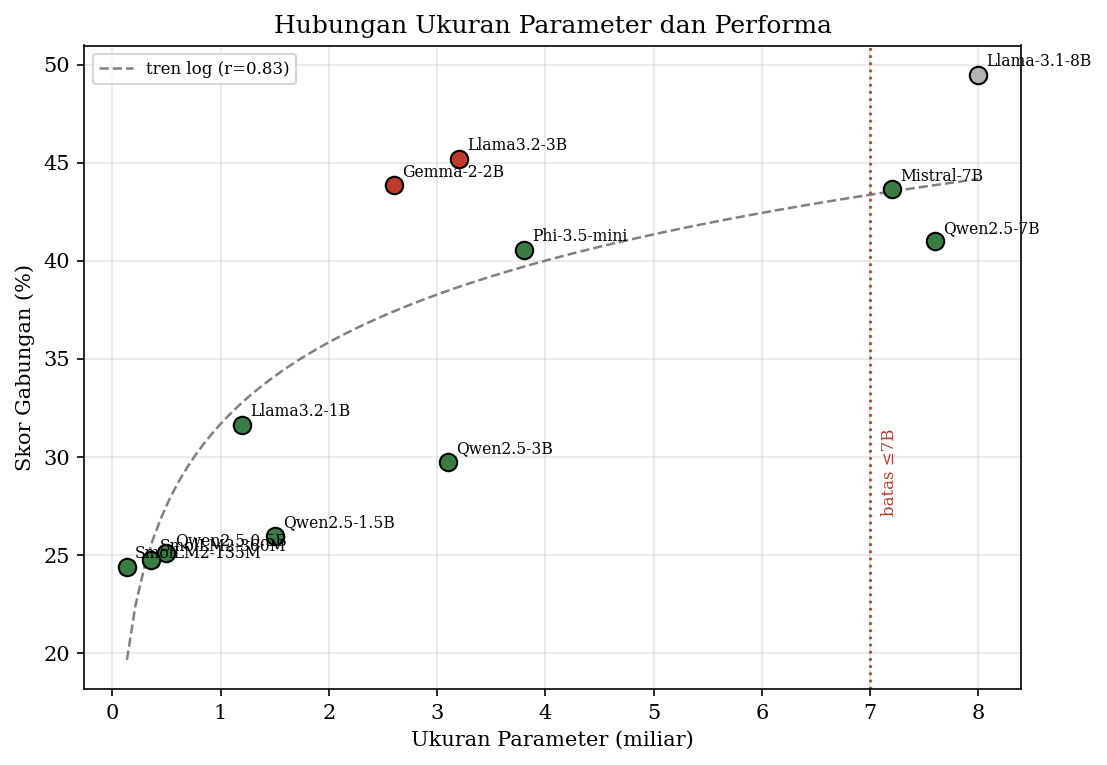

In [6]:
def fig4_scatter_param():
    fig, ax = plt.subplots(figsize=(7.5,5.2))
    for m in s.model_name:
        x, y = PARAMS[m], s[s.model_name==m].final_score_50_50.iloc[0]
        col = C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[m] else C_ELIG)
        ax.scatter(x, y, s=70, color=col, edgecolor="black", zorder=3)
        ax.annotate(m, (x,y), fontsize=7.5, xytext=(4,4), textcoords="offset points")
    xs = np.array([PARAMS[m] for m in s.model_name]); ys = s.final_score_50_50.values
    a,b = np.polyfit(np.log(xs), ys, 1); xg = np.linspace(xs.min(), xs.max(), 100)
    ax.plot(xg, a*np.log(xg)+b, ls="--", color="gray", lw=1.2, label=f"tren log (r={np.corrcoef(np.log(xs),ys)[0,1]:.2f})")
    ax.axvline(7, ls=":", color=C_TOP, lw=1.3); ax.text(7.1, 27, "batas ≤7B", color=C_TOP, fontsize=8, rotation=90, va="bottom")
    ax.set_xlabel("Ukuran Parameter (miliar)"); ax.set_ylabel("Skor Gabungan (%)")
    ax.set_title("Hubungan Ukuran Parameter dan Performa"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig("fig4_param_vs_skor.png", bbox_inches="tight"); plt.show()

fig4_scatter_param()

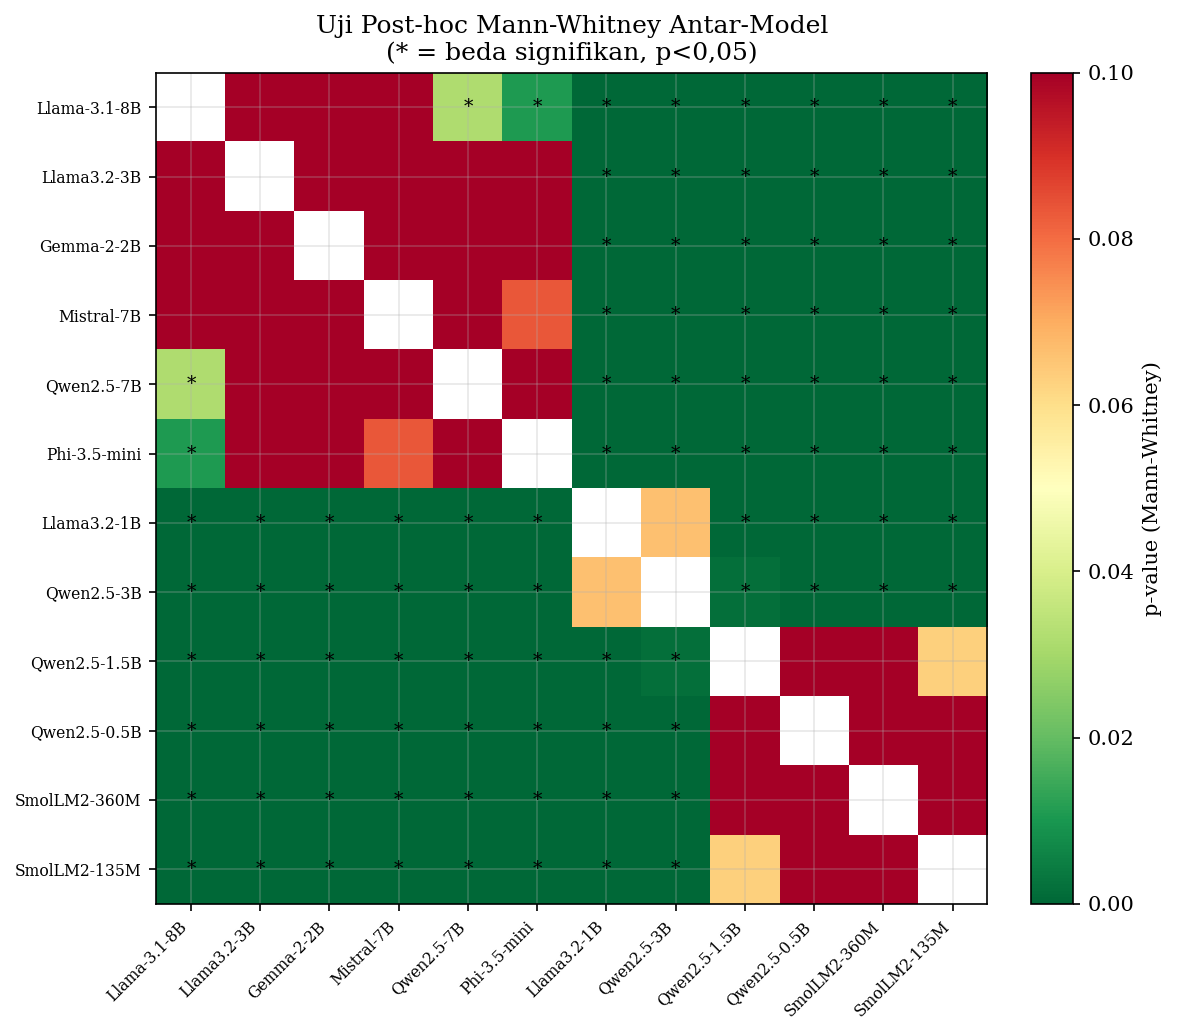

In [7]:
def fig5_heatmap_mw():
    order = list(s.model_name)
    n = len(order); M = np.full((n,n), np.nan)
    pv = {(r["Model A"], r["Model B"]): r["p-value"] for _,r in mw.iterrows()}
    for i,a in enumerate(order):
        for j,b in enumerate(order):
            if i==j: continue
            p = pv.get((a,b), pv.get((b,a)))
            if p is not None: M[i,j] = p
    fig, ax = plt.subplots(figsize=(8.5,7))
    im = ax.imshow(M, cmap="RdYlGn_r", vmin=0, vmax=.1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(order, rotation=45, ha="right", fontsize=7.5); ax.set_yticklabels(order, fontsize=7.5)
    for i in range(n):
        for j in range(n):
            if not np.isnan(M[i,j]):
                ax.text(j,i, "*" if M[i,j]<.05 else "", ha="center", va="center", fontsize=9)
    cb = fig.colorbar(im, ax=ax, fraction=.046, pad=.04); cb.set_label("p-value (Mann-Whitney)")
    ax.set_title("Uji Post-hoc Mann-Whitney Antar-Model\n(* = beda signifikan, p<0,05)")
    plt.tight_layout(); plt.savefig("fig5_heatmap_mannwhitney.png", bbox_inches="tight"); plt.show()

fig5_heatmap_mw()

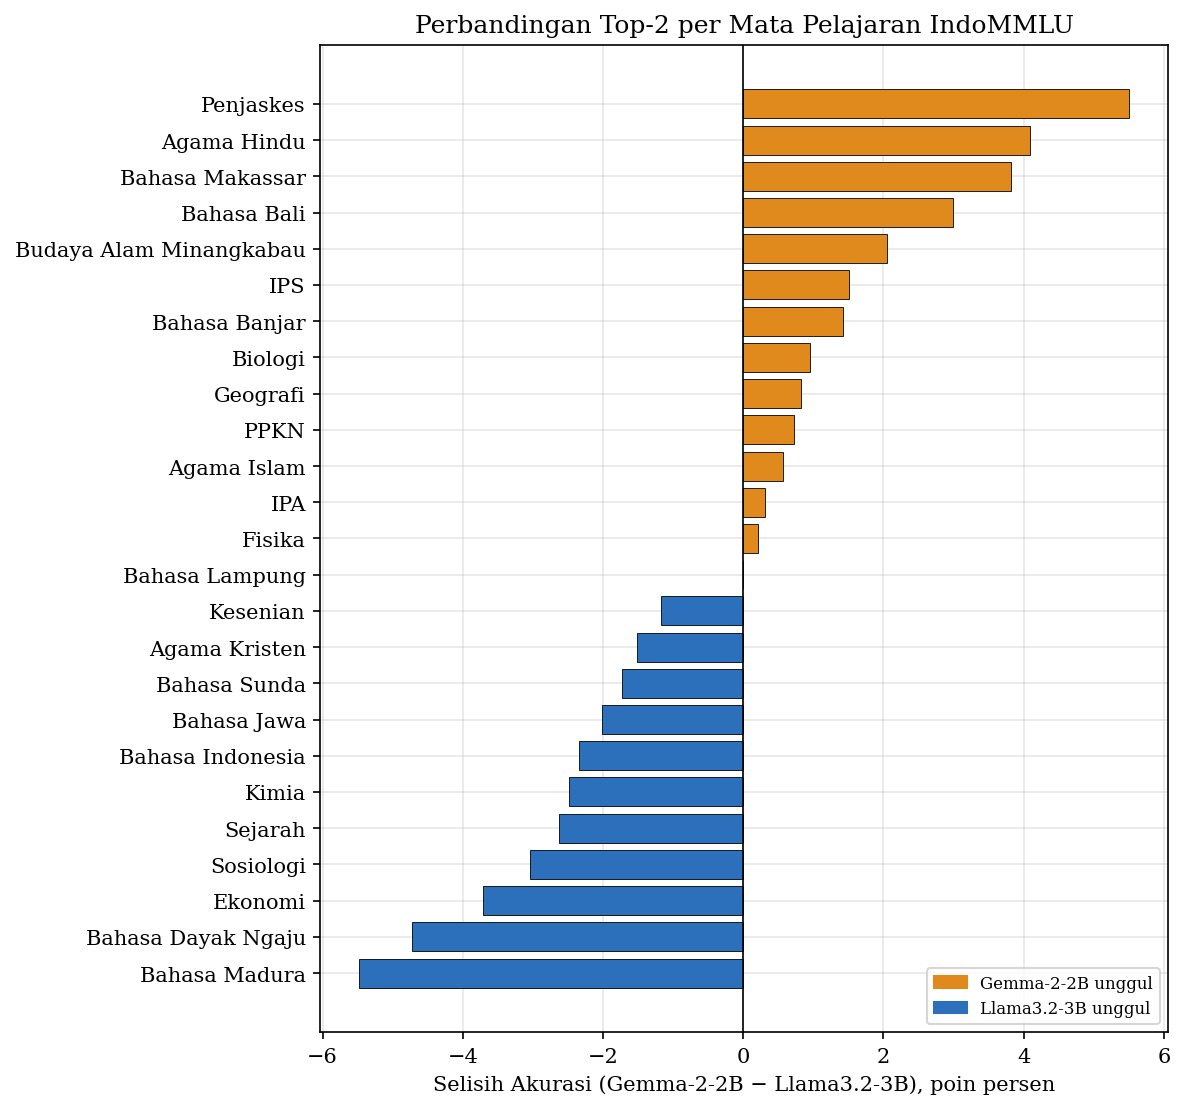

In [8]:
def fig6_top2_mmlu_subject():
    mc = [c for c in k.columns if c.startswith("mmlu_")]
    l = k[k.model=="Llama3.2-3B"][mc].iloc[0]; g = k[k.model=="Gemma-2-2B"][mc].iloc[0]
    diff = (g - l).sort_values(); labels = [c.replace("mmlu_","") for c in diff.index]
    colors = [C_CAR if v>0 else C_MMLU for v in diff.values]
    fig, ax = plt.subplots(figsize=(8,7.5))
    ax.barh(labels, diff.values, color=colors, edgecolor="black", linewidth=.4)
    ax.axvline(0, color="black", lw=.8)
    ax.set_xlabel("Selisih Akurasi (Gemma-2-2B − Llama3.2-3B), poin persen")
    ax.set_title("Perbandingan Top-2 per Mata Pelajaran IndoMMLU")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=C_CAR,label="Gemma-2-2B unggul"),
                       Patch(color=C_MMLU,label="Llama3.2-3B unggul")], fontsize=8, loc="lower right")
    plt.tight_layout(); plt.savefig("fig6_top2_per_subjek.png", bbox_inches="tight"); plt.show()

fig6_top2_mmlu_subject()

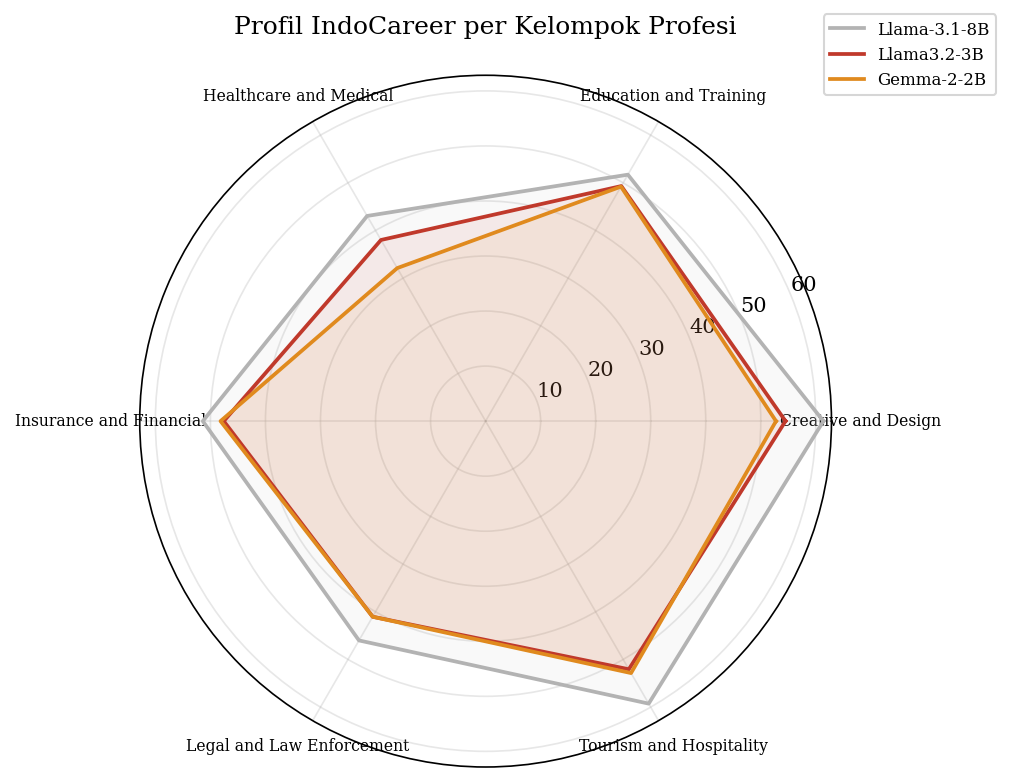

In [9]:
def fig7_career_radar():
    cats = [c for c in cr.columns if c not in ("rank","model","indocareer_acc")]
    ang = np.linspace(0, 2*np.pi, len(cats), endpoint=False).tolist(); ang += ang[:1]
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    for m,col in [("Llama-3.1-8B",C_DQ),("Llama3.2-3B",C_TOP),("Gemma-2-2B",C_CAR)]:
        v = cr[cr.model==m][cats].iloc[0].tolist(); v += v[:1]
        ax.plot(ang, v, color=col, lw=1.8, label=m); ax.fill(ang, v, color=col, alpha=.08)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(cats, fontsize=7.5)
    ax.set_title("Profil IndoCareer per Kelompok Profesi", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25,1.1), fontsize=8)
    plt.tight_layout(); plt.savefig("fig7_career_radar.png", bbox_inches="tight"); plt.show()

fig7_career_radar()

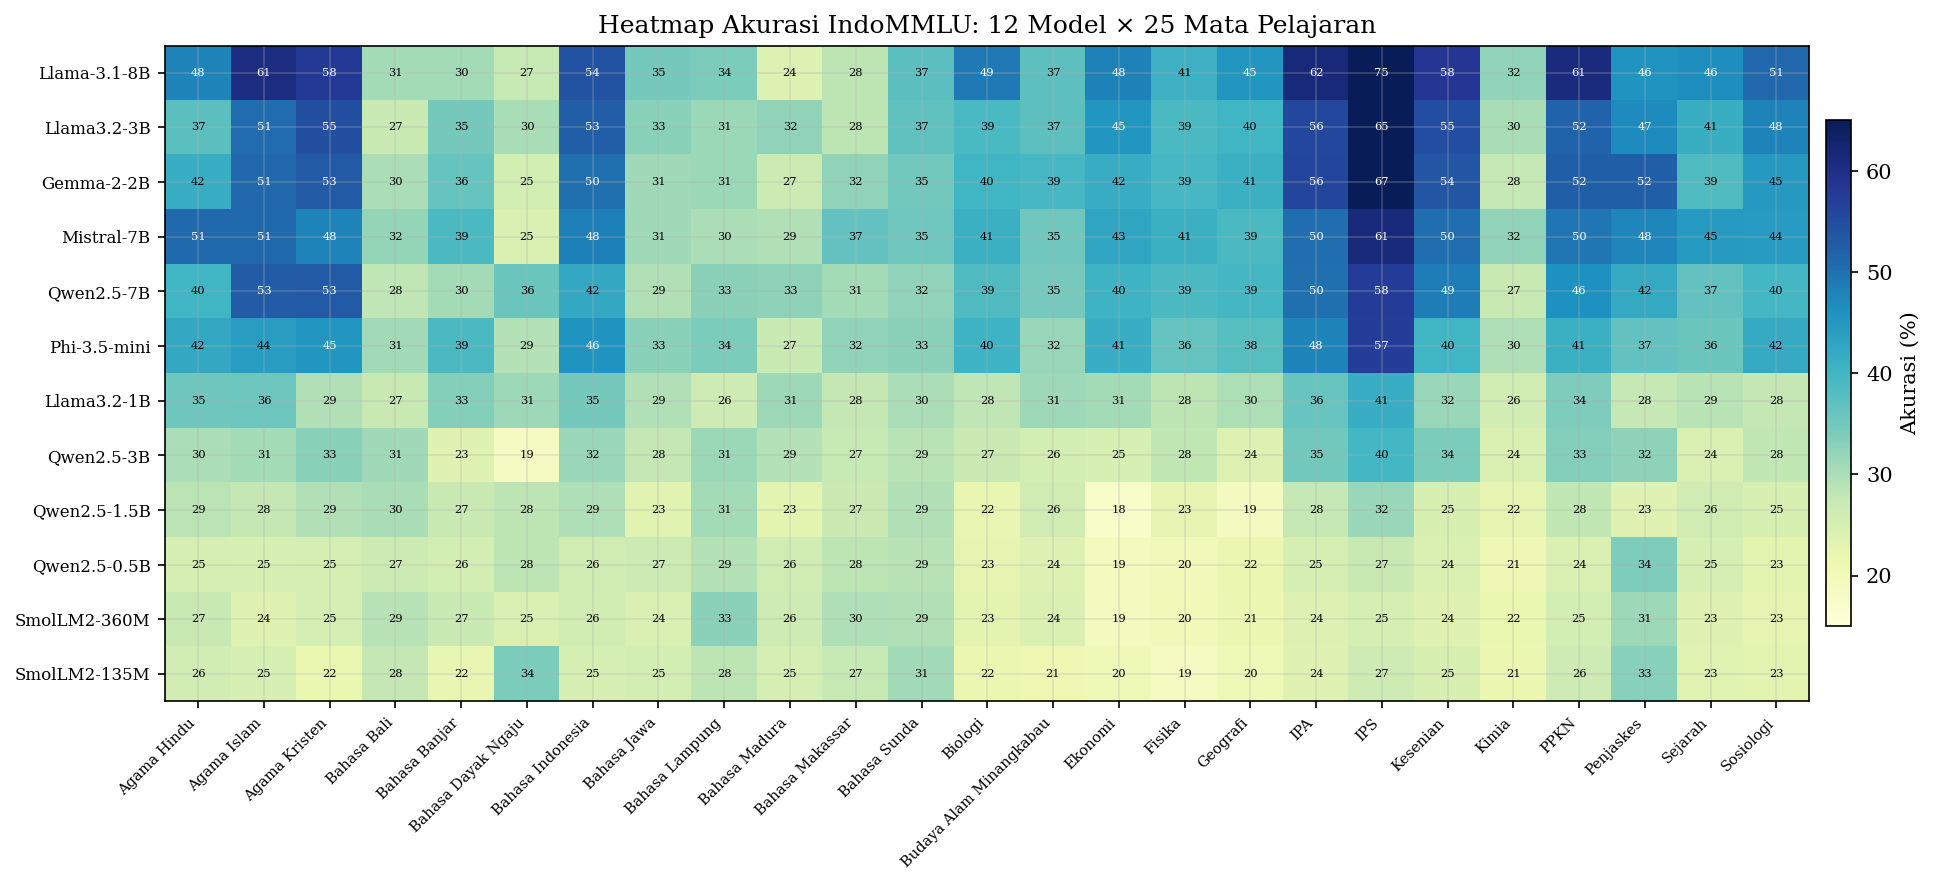

In [10]:
def fig8_heatmap_mmlu():
    m = _mmlu_matrix()
    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(m.values, cmap="YlGnBu", vmin=15, vmax=65, aspect="auto")
    ax.set_xticks(range(m.shape[1])); ax.set_yticks(range(m.shape[0]))
    ax.set_xticklabels(m.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(m.index, fontsize=8)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i,j]
            ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=5.5,
                    color="white" if v>45 else "black")
    cb = fig.colorbar(im, ax=ax, fraction=.015, pad=.01); cb.set_label("Akurasi (%)")
    ax.set_title("Heatmap Akurasi IndoMMLU: 12 Model × 25 Mata Pelajaran")
    plt.tight_layout(); plt.savefig("fig8_heatmap_mmlu.png", bbox_inches="tight"); plt.show()

fig8_heatmap_mmlu()

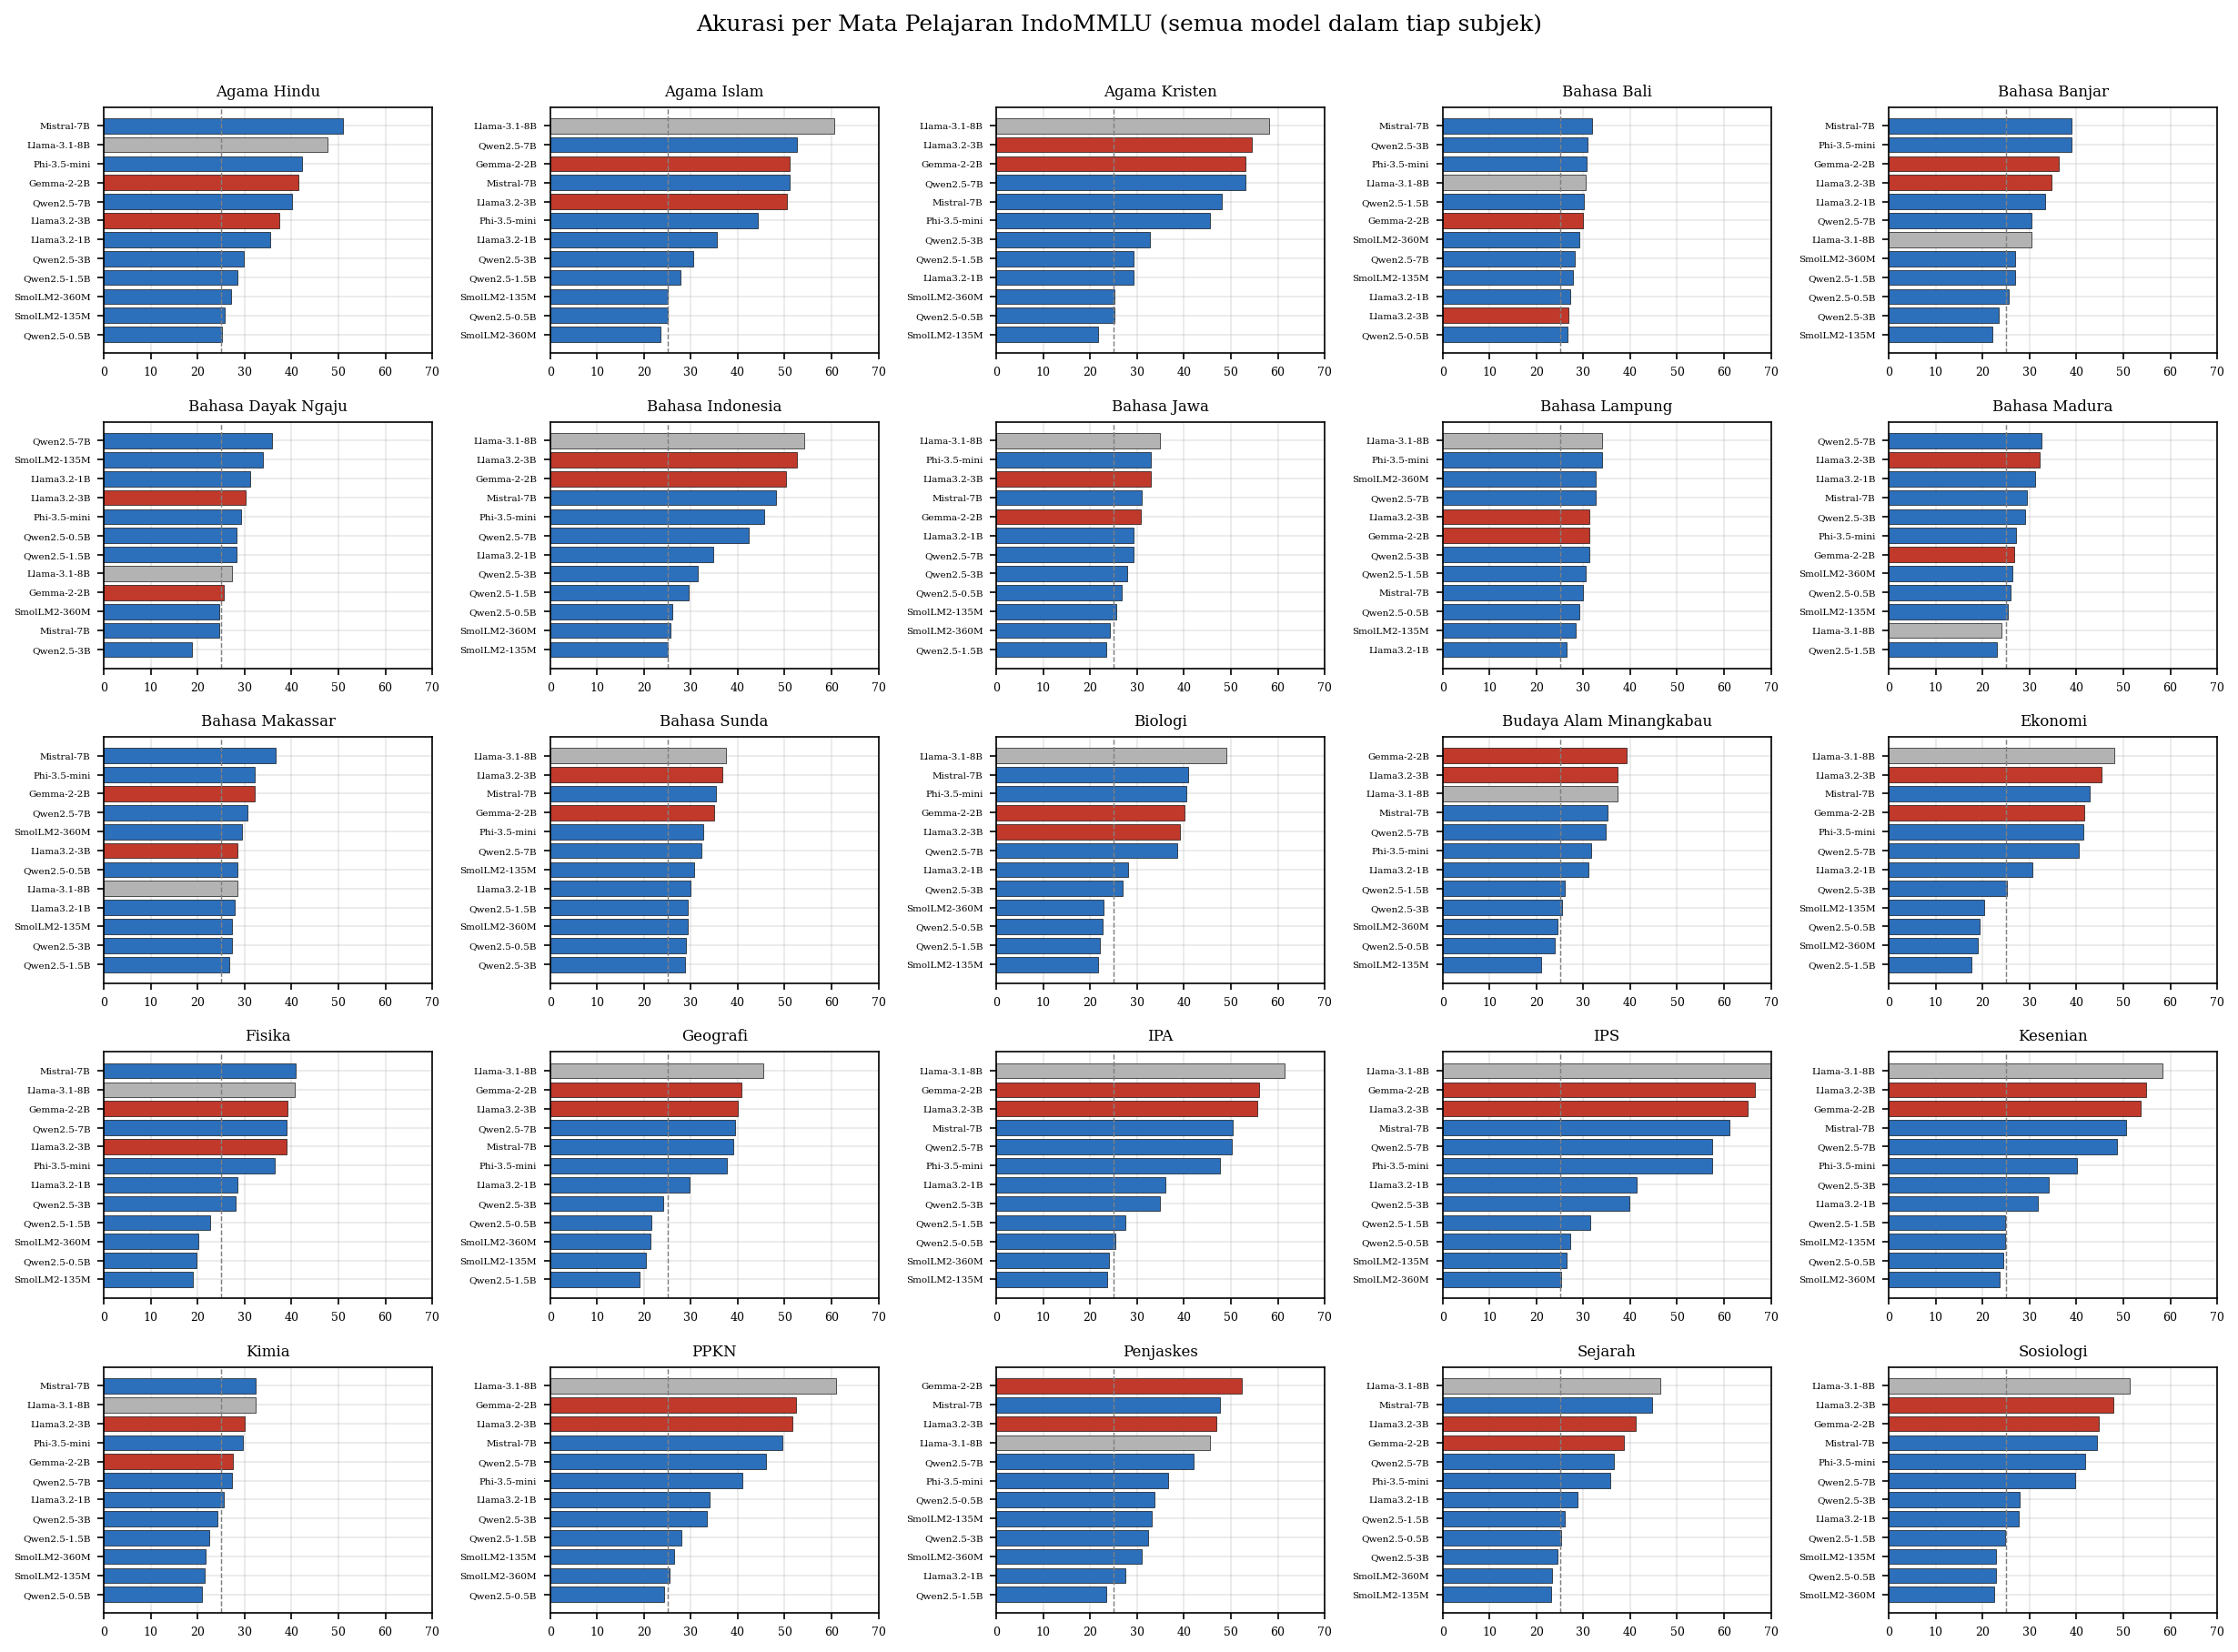

In [11]:
def fig9_grid_mmlu_per_subjek():
    m = _mmlu_matrix(); subs = list(m.columns)
    ncol=5; nrow=int(np.ceil(len(subs)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.3, nrow*2.4))
    for idx, sub in enumerate(subs):
        ax = axes.flat[idx]; d = m[sub].sort_values()
        colors=[C_TOP if mm in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[mm] else C_MMLU) for mm in d.index]
        ax.barh(range(len(d)), d.values, color=colors, edgecolor="black", linewidth=.3)
        ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=5)
        ax.axvline(25, ls="--", color="gray", lw=.7); ax.set_title(sub, fontsize=8)
        ax.set_xlim(0,70); ax.tick_params(axis="x", labelsize=6)
    for j in range(len(subs), nrow*ncol): axes.flat[j].axis("off")
    fig.suptitle("Akurasi per Mata Pelajaran IndoMMLU (semua model dalam tiap subjek)", fontsize=12, y=1.005)
    plt.tight_layout(); plt.savefig("fig9_grid_mmlu_per_subjek.png", bbox_inches="tight"); plt.show()

fig9_grid_mmlu_per_subjek()

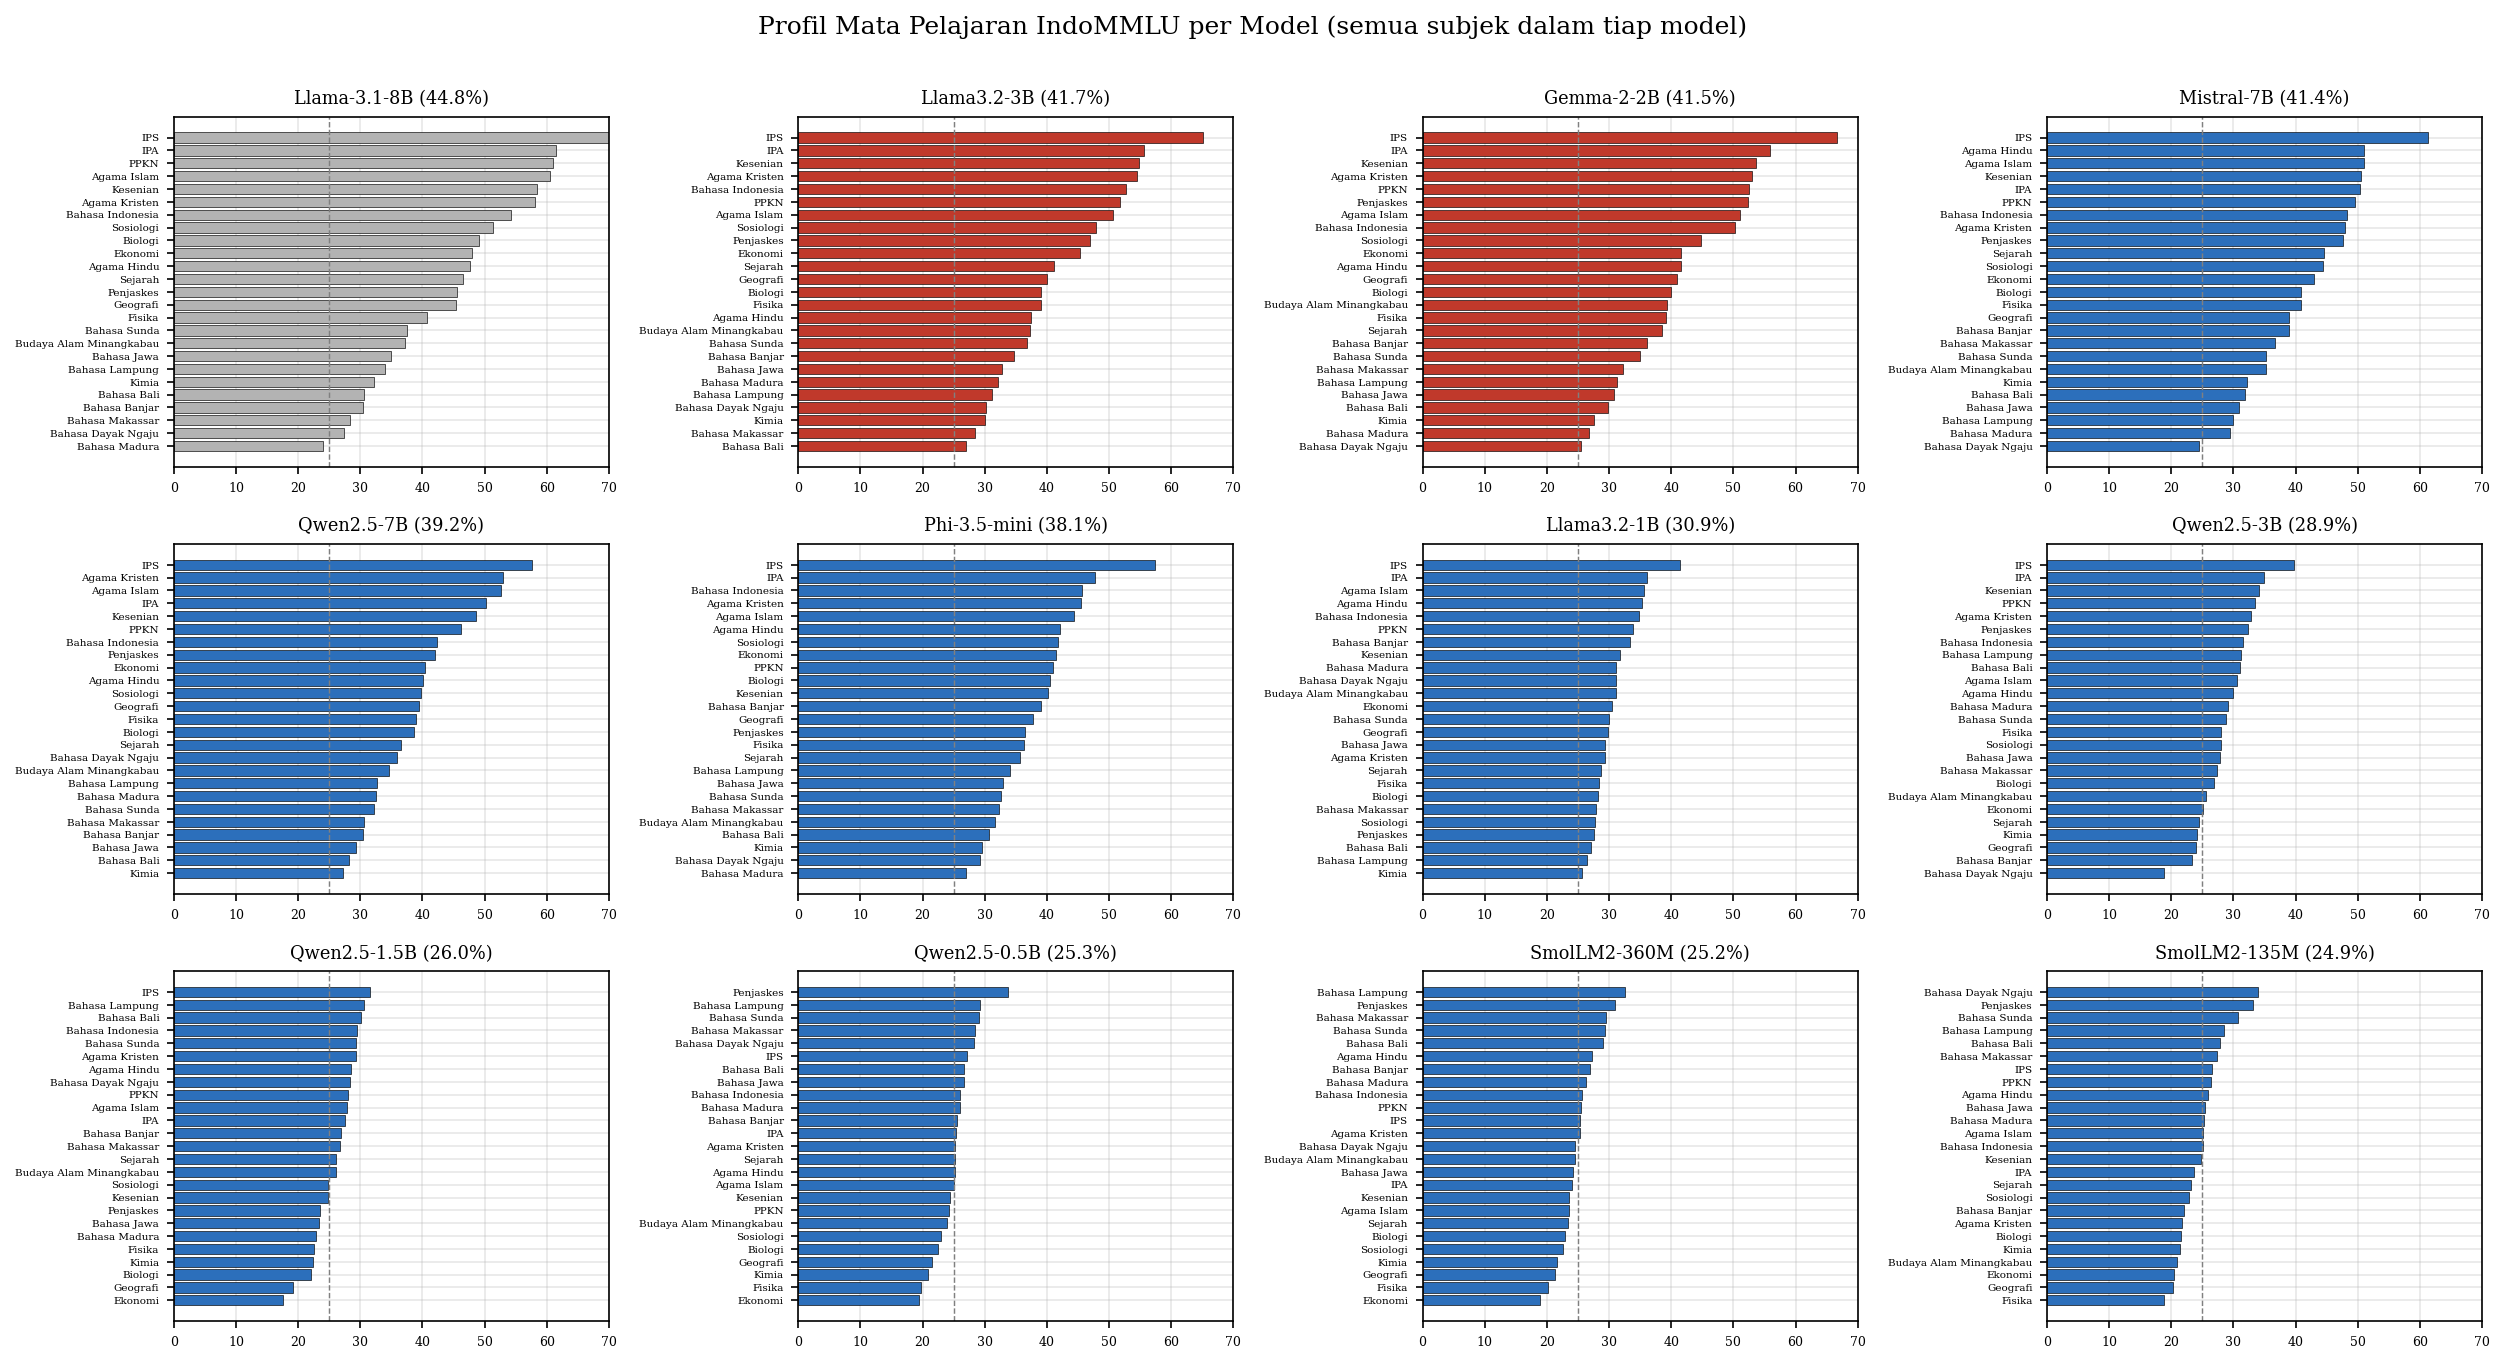

In [12]:
def fig10_grid_mmlu_per_model():
    m = _mmlu_matrix()
    ncol=4; nrow=int(np.ceil(len(m.index)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*4.2, nrow*3.0))
    for idx, mdl in enumerate(m.index):
        ax = axes.flat[idx]; d = m.loc[mdl].sort_values()
        col = C_TOP if mdl in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[mdl] else C_MMLU)
        ax.barh(range(len(d)), d.values, color=col, edgecolor="black", linewidth=.3)
        ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=5)
        ax.axvline(25, ls="--", color="gray", lw=.7)
        ax.set_title(f"{mdl} ({m.loc[mdl].mean():.1f}%)", fontsize=8.5)
        ax.set_xlim(0,70); ax.tick_params(axis="x", labelsize=6)
    for j in range(len(m.index), nrow*ncol): axes.flat[j].axis("off")
    fig.suptitle("Profil Mata Pelajaran IndoMMLU per Model (semua subjek dalam tiap model)", fontsize=12, y=1.005)
    plt.tight_layout(); plt.savefig("fig10_grid_mmlu_per_model.png", bbox_inches="tight"); plt.show()

fig10_grid_mmlu_per_model()

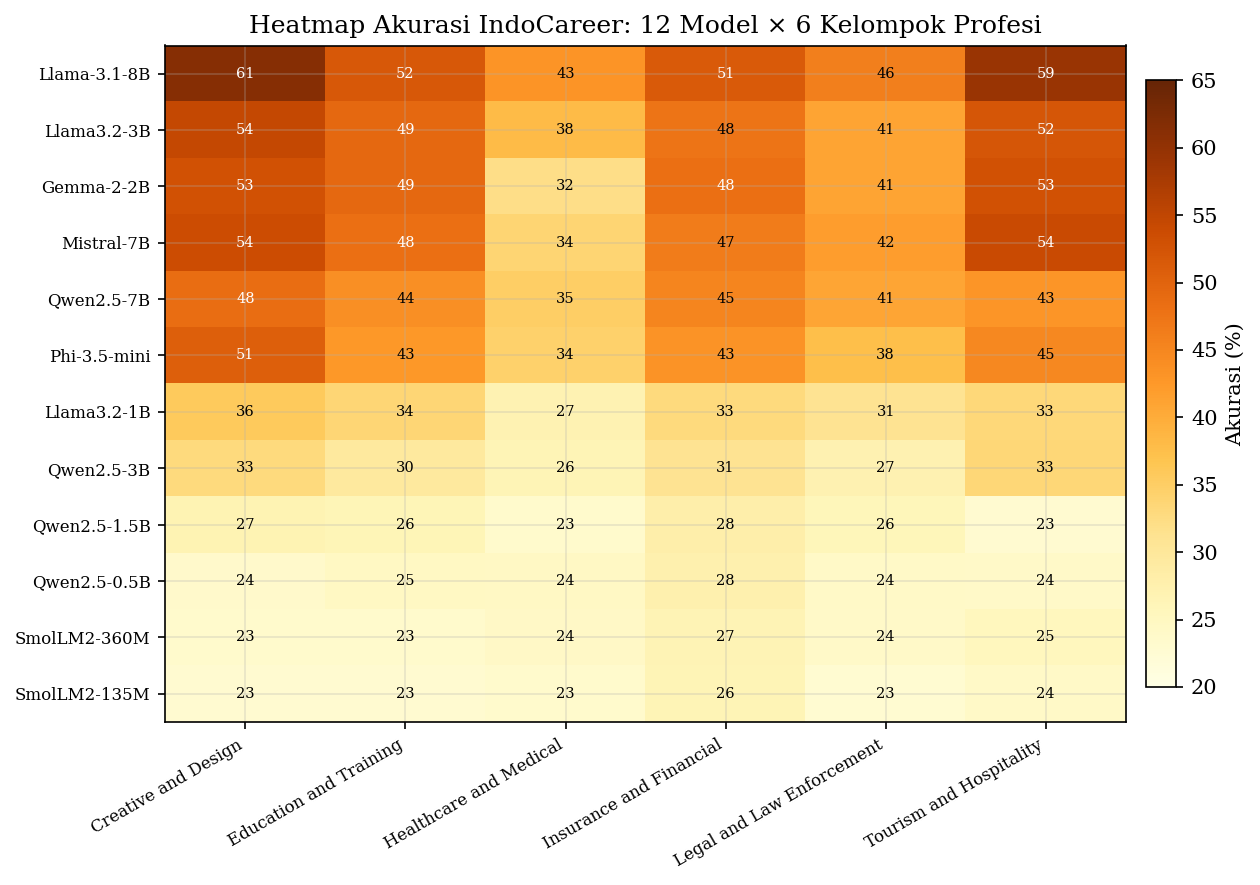

In [13]:
def fig11_heatmap_career():
    m = _career_matrix()
    fig, ax = plt.subplots(figsize=(8.5, 6))
    im = ax.imshow(m.values, cmap="YlOrBr", vmin=20, vmax=65, aspect="auto")
    ax.set_xticks(range(m.shape[1])); ax.set_yticks(range(m.shape[0]))
    ax.set_xticklabels(m.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(m.index, fontsize=8)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v=m.values[i,j]
            ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=7,
                    color="white" if v>48 else "black")
    cb=fig.colorbar(im, ax=ax, fraction=.03, pad=.02); cb.set_label("Akurasi (%)")
    ax.set_title("Heatmap Akurasi IndoCareer: 12 Model × 6 Kelompok Profesi")
    plt.tight_layout(); plt.savefig("fig11_heatmap_career.png", bbox_inches="tight"); plt.show()

fig11_heatmap_career()

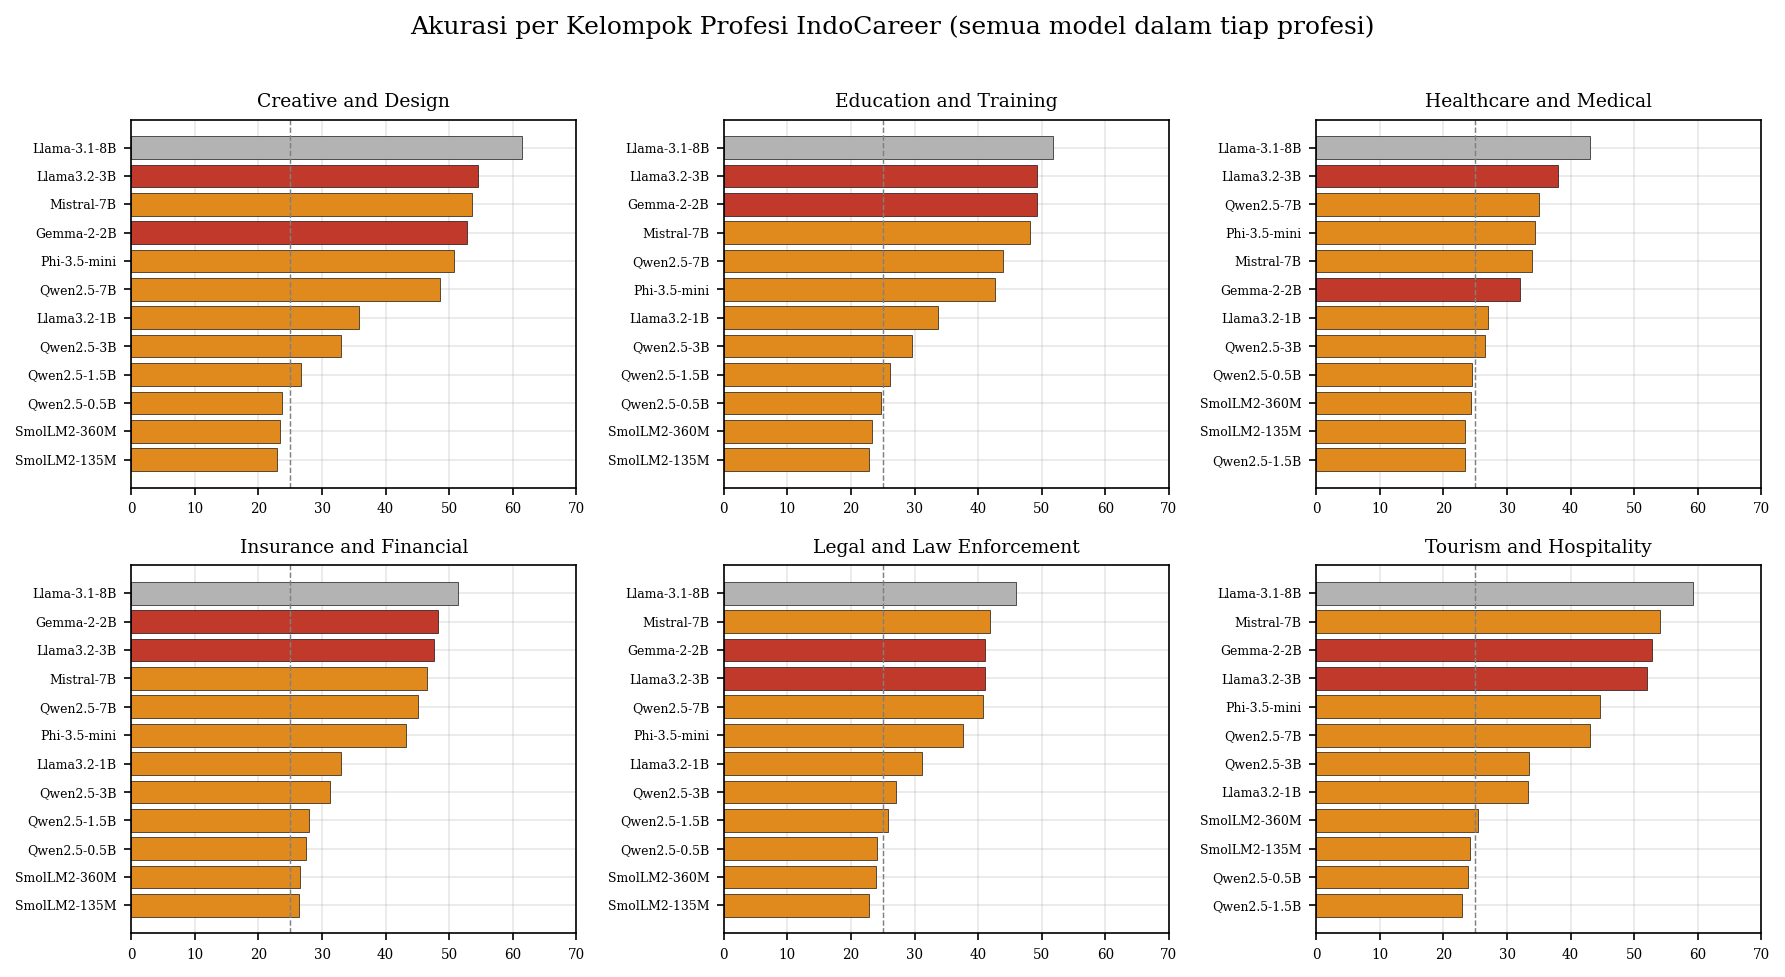

In [14]:
def fig12_grid_career_per_profesi():
    m = _career_matrix(); profs=list(m.columns)
    ncol=3; nrow=2
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*4.0, nrow*3.2))
    for idx, pr in enumerate(profs):
        ax=axes.flat[idx]; d=m[pr].sort_values()
        colors=[C_TOP if mm in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[mm] else C_CAR) for mm in d.index]
        ax.barh(range(len(d)), d.values, color=colors, edgecolor="black", linewidth=.3)
        ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=6)
        ax.axvline(25, ls="--", color="gray", lw=.7); ax.set_title(pr, fontsize=9)
        ax.set_xlim(0,70); ax.tick_params(axis="x", labelsize=6.5)
    fig.suptitle("Akurasi per Kelompok Profesi IndoCareer (semua model dalam tiap profesi)", fontsize=12, y=1.01)
    plt.tight_layout(); plt.savefig("fig12_grid_career_per_profesi.png", bbox_inches="tight"); plt.show()

fig12_grid_career_per_profesi()

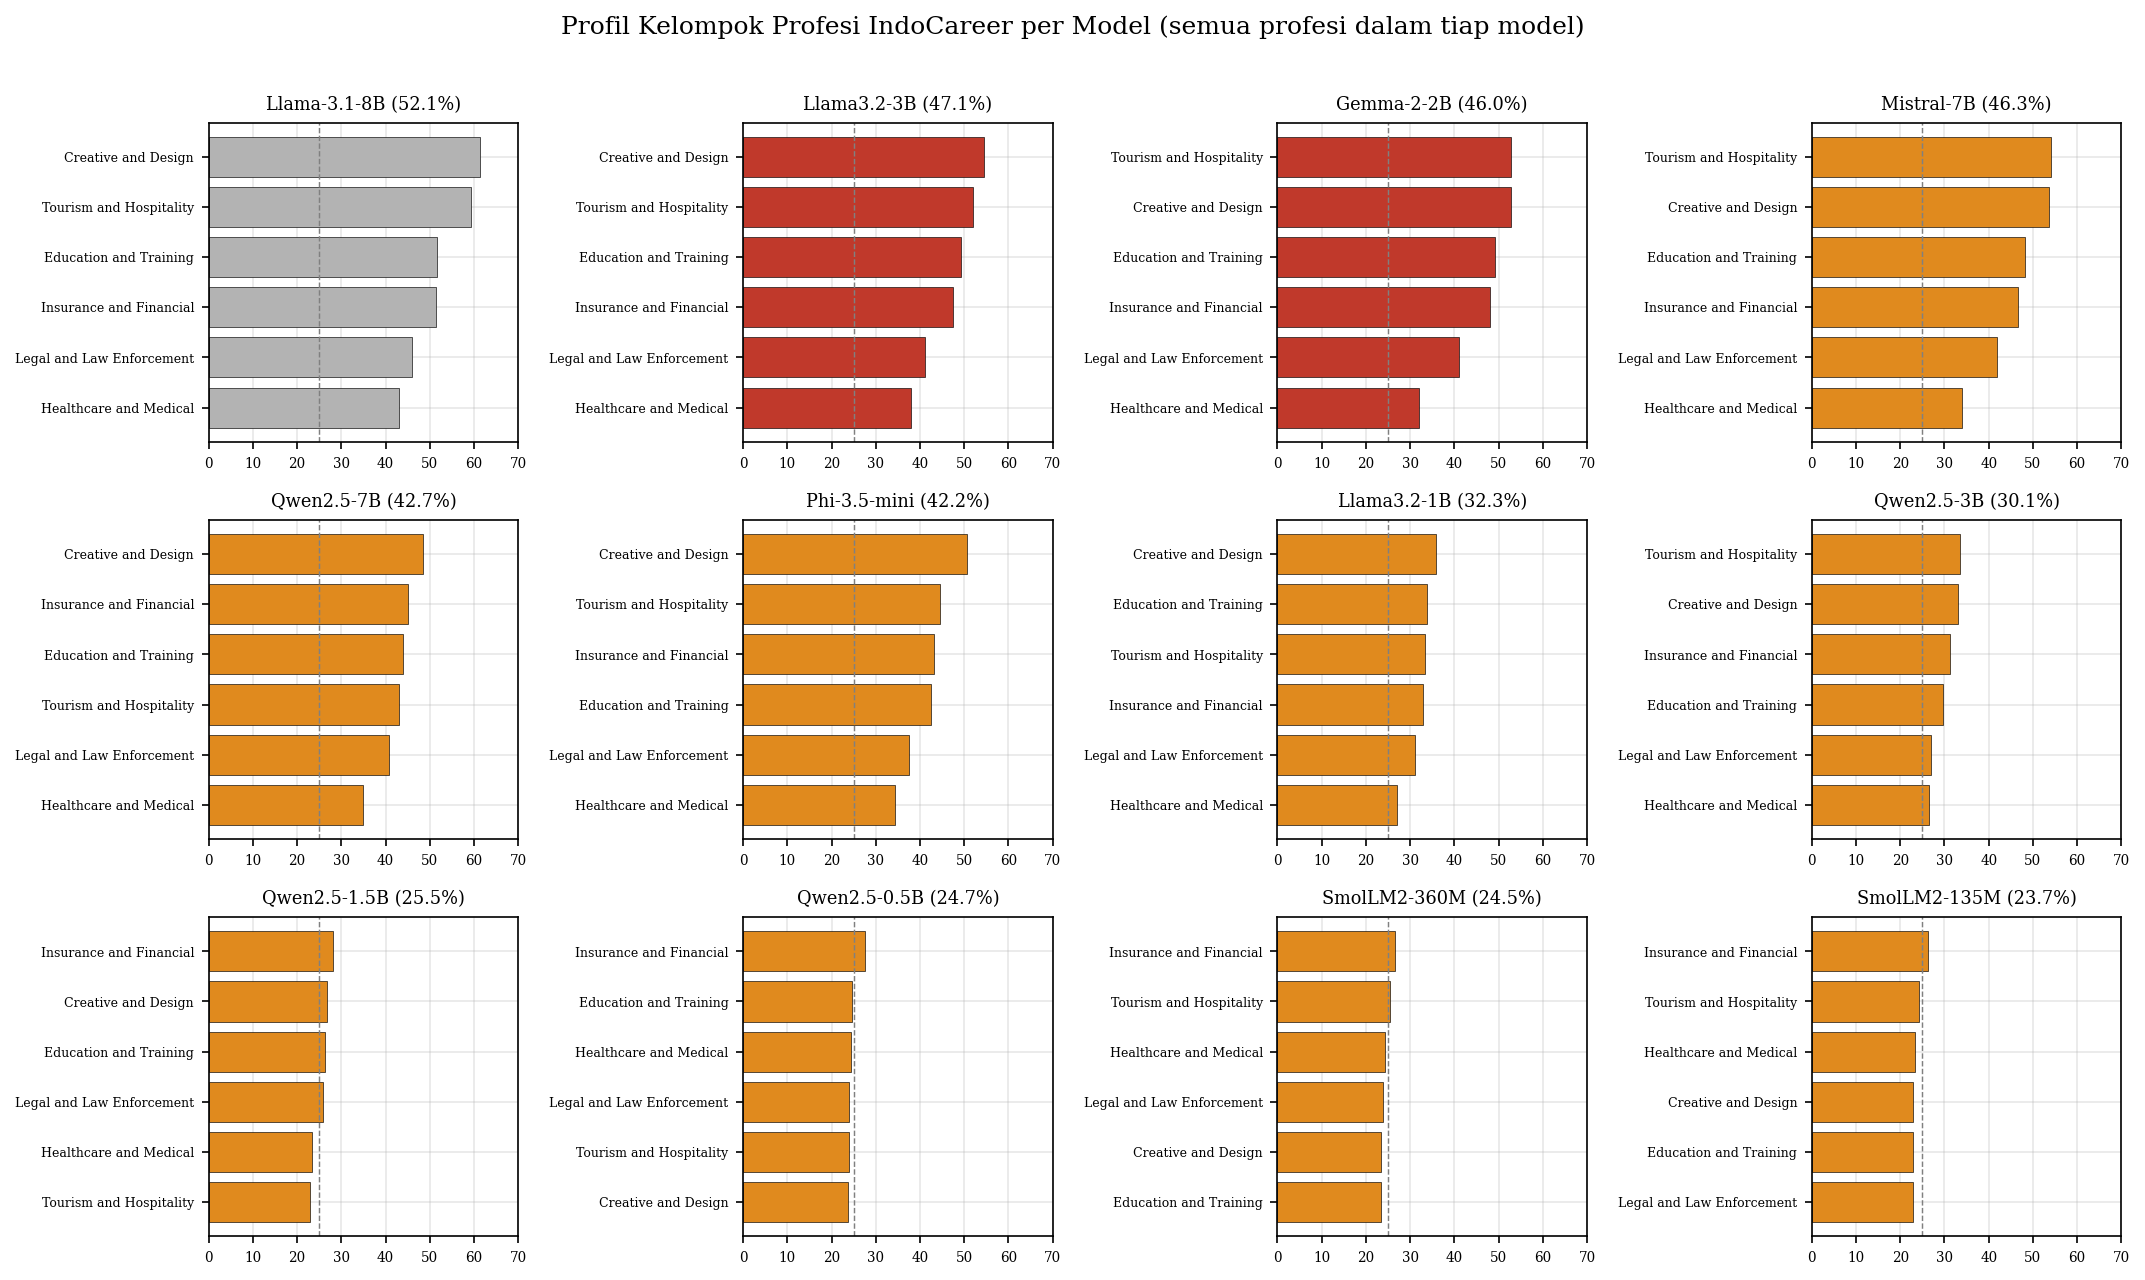

In [15]:
def fig13_grid_career_per_model():
    m = _career_matrix()
    ncol=4; nrow=3
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.6, nrow*2.8))
    for idx, mdl in enumerate(m.index):
        ax=axes.flat[idx]; d=m.loc[mdl].sort_values()
        col=C_TOP if mdl in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[mdl] else C_CAR)
        ax.barh(range(len(d)), d.values, color=col, edgecolor="black", linewidth=.3)
        ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=6)
        ax.axvline(25, ls="--", color="gray", lw=.7)
        ax.set_title(f"{mdl} ({m.loc[mdl].mean():.1f}%)", fontsize=8.5)
        ax.set_xlim(0,70); ax.tick_params(axis="x", labelsize=6.5)
    for j in range(len(m.index), nrow*ncol): axes.flat[j].axis("off")
    fig.suptitle("Profil Kelompok Profesi IndoCareer per Model (semua profesi dalam tiap model)", fontsize=12, y=1.01)
    plt.tight_layout(); plt.savefig("fig13_grid_career_per_model.png", bbox_inches="tight"); plt.show()

fig13_grid_career_per_model()

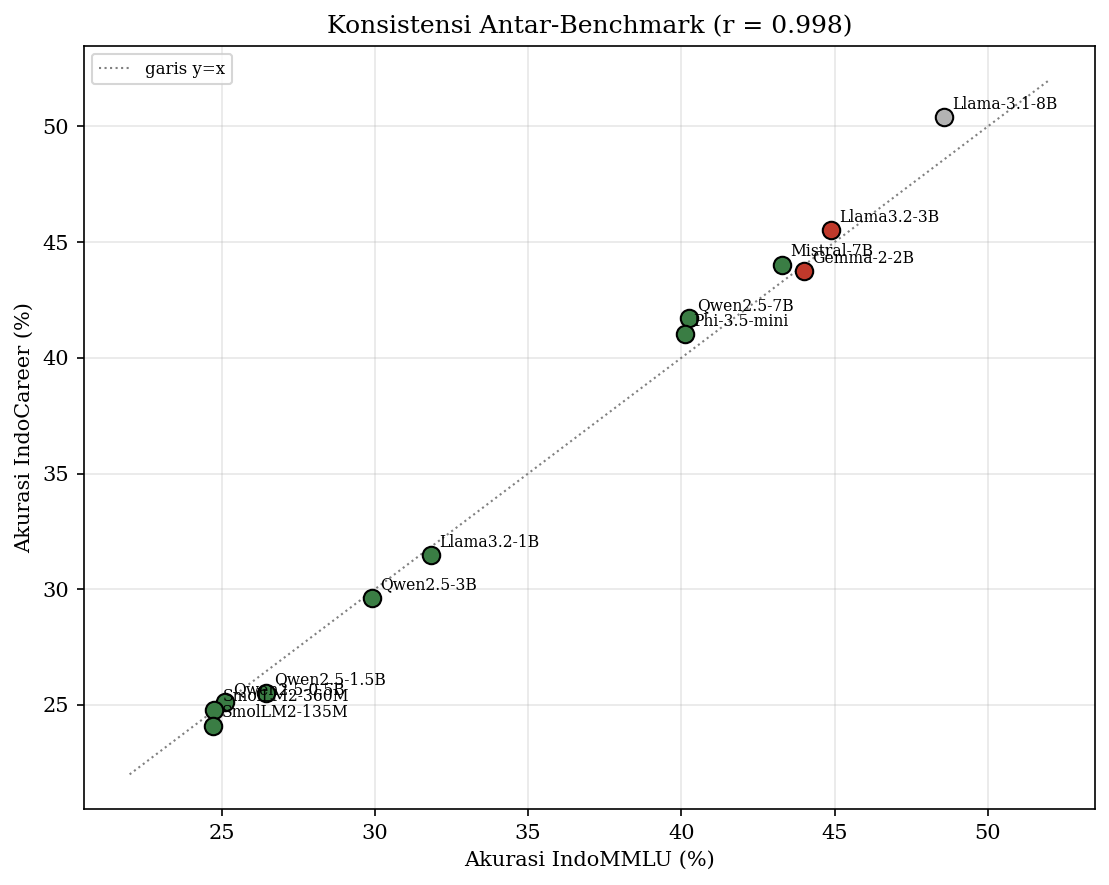

In [16]:
def fig14_scatter_mmlu_vs_career():
    fig, ax = plt.subplots(figsize=(7.5,6))
    for m in s.model_name:
        x=s[s.model_name==m].indommlu_acc.iloc[0]; y=s[s.model_name==m].indocareer_acc.iloc[0]
        col=C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[m] else C_ELIG)
        ax.scatter(x,y,s=70,color=col,edgecolor="black",zorder=3)
        ax.annotate(m,(x,y),fontsize=7.5,xytext=(4,4),textcoords="offset points")
    lo,hi=22,52; ax.plot([lo,hi],[lo,hi],ls=":",color="gray",lw=1,label="garis y=x")
    r=np.corrcoef(s.indommlu_acc,s.indocareer_acc)[0,1]
    ax.set_xlabel("Akurasi IndoMMLU (%)"); ax.set_ylabel("Akurasi IndoCareer (%)")
    ax.set_title(f"Konsistensi Antar-Benchmark (r = {r:.3f})"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig("fig14_scatter_mmlu_vs_career.png", bbox_inches="tight"); plt.show()

fig14_scatter_mmlu_vs_career()

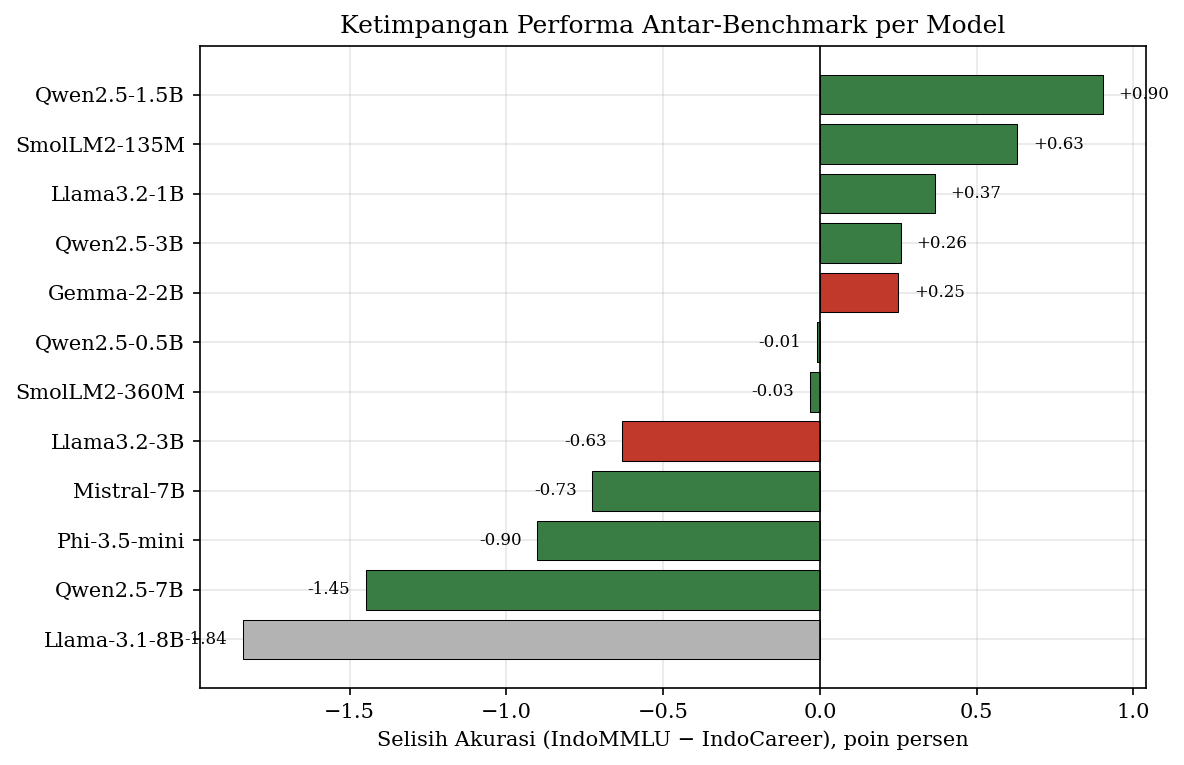

In [17]:
def fig15_selisih_benchmark():
    d=s.copy(); d["selisih"]=d.indommlu_acc-d.indocareer_acc; d=d.sort_values("selisih")
    colors=[C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[m] else C_ELIG) for m in d.model_name]
    fig,ax=plt.subplots(figsize=(8,5.2))
    ax.barh(d.model_name,d.selisih,color=colors,edgecolor="black",linewidth=.5)
    ax.axvline(0,color="black",lw=.8)
    for y,v in enumerate(d.selisih): ax.text(v+(.05 if v>=0 else -.05),y,f"{v:+.2f}",va="center",ha="left" if v>=0 else "right",fontsize=8)
    ax.set_xlabel("Selisih Akurasi (IndoMMLU − IndoCareer), poin persen")
    ax.set_title("Ketimpangan Performa Antar-Benchmark per Model")
    plt.tight_layout(); plt.savefig("fig15_selisih_benchmark.png", bbox_inches="tight"); plt.show()

fig15_selisih_benchmark()

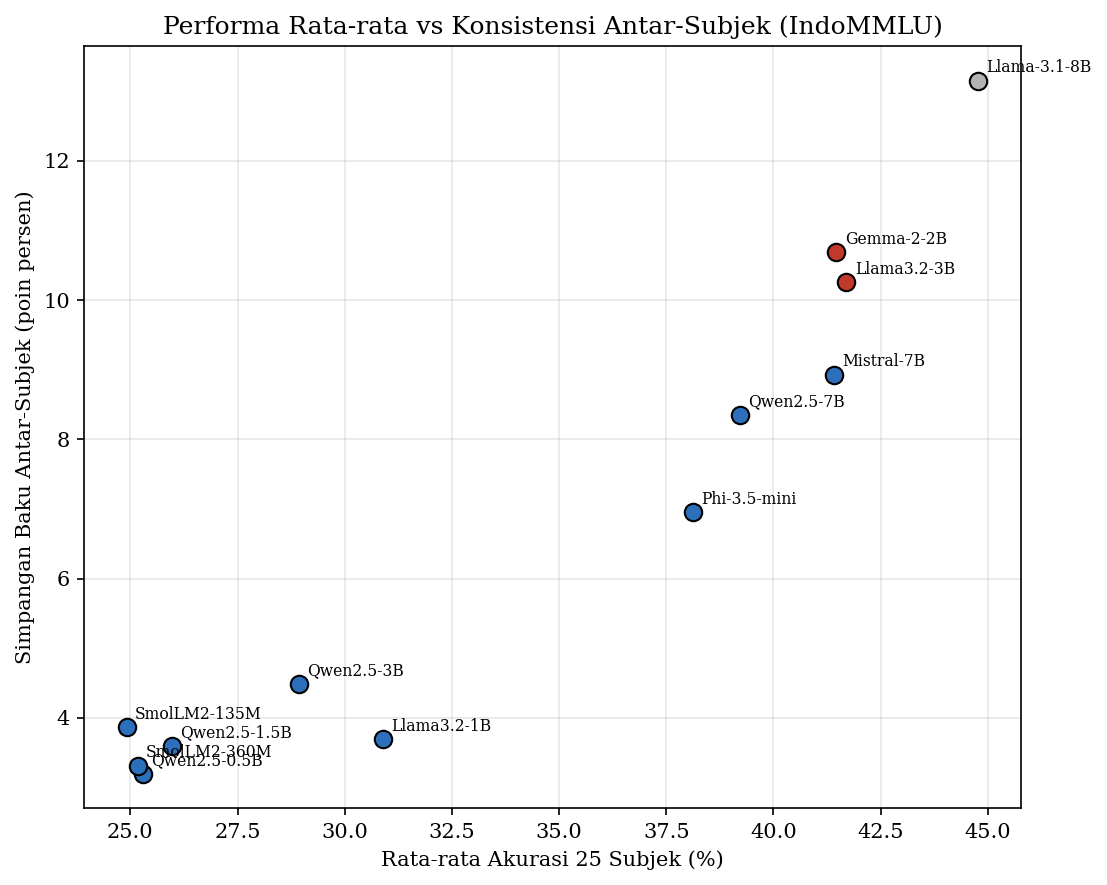

In [18]:
def fig16_konsistensi_mmlu():
    m=_mmlu_matrix(); d=pd.DataFrame({"mean":m.mean(axis=1),"std":m.std(axis=1)}).loc[s.model_name]
    fig,ax=plt.subplots(figsize=(7.5,6))
    for mdl in d.index:
        col=C_TOP if mdl in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[mdl] else C_MMLU)
        ax.scatter(d.loc[mdl,"mean"],d.loc[mdl,"std"],s=70,color=col,edgecolor="black",zorder=3)
        ax.annotate(mdl,(d.loc[mdl,"mean"],d.loc[mdl,"std"]),fontsize=7.5,xytext=(4,4),textcoords="offset points")
    ax.set_xlabel("Rata-rata Akurasi 25 Subjek (%)"); ax.set_ylabel("Simpangan Baku Antar-Subjek (poin persen)")
    ax.set_title("Performa Rata-rata vs Konsistensi Antar-Subjek (IndoMMLU)")
    plt.tight_layout(); plt.savefig("fig16_konsistensi_mmlu.png", bbox_inches="tight"); plt.show()

fig16_konsistensi_mmlu()

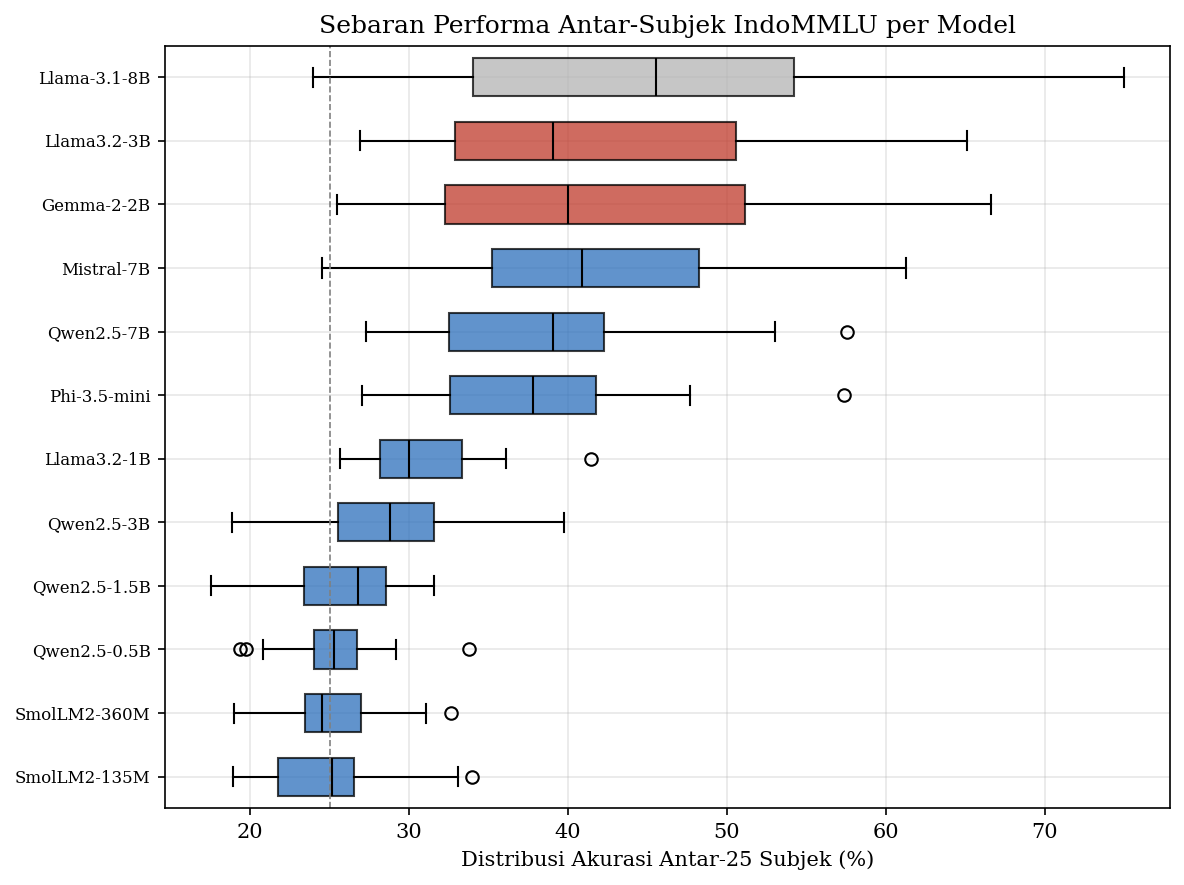

In [19]:
def fig17_boxplot_mmlu():
    m=_mmlu_matrix().loc[s.sort_values("indommlu_acc").model_name]
    fig,ax=plt.subplots(figsize=(8,6))
    bp=ax.boxplot([m.loc[mdl].values for mdl in m.index],vert=False,patch_artist=True,widths=.6)
    for patch,mdl in zip(bp["boxes"],m.index):
        patch.set_facecolor(C_TOP if mdl in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[mdl] else C_MMLU))
        patch.set_alpha(.75)
    for med in bp["medians"]: med.set_color("black")
    ax.set_yticklabels(m.index,fontsize=8); ax.axvline(25,ls="--",color="gray",lw=.8)
    ax.set_xlabel("Distribusi Akurasi Antar-25 Subjek (%)")
    ax.set_title("Sebaran Performa Antar-Subjek IndoMMLU per Model")
    plt.tight_layout(); plt.savefig("fig17_boxplot_mmlu.png", bbox_inches="tight"); plt.show()

fig17_boxplot_mmlu()

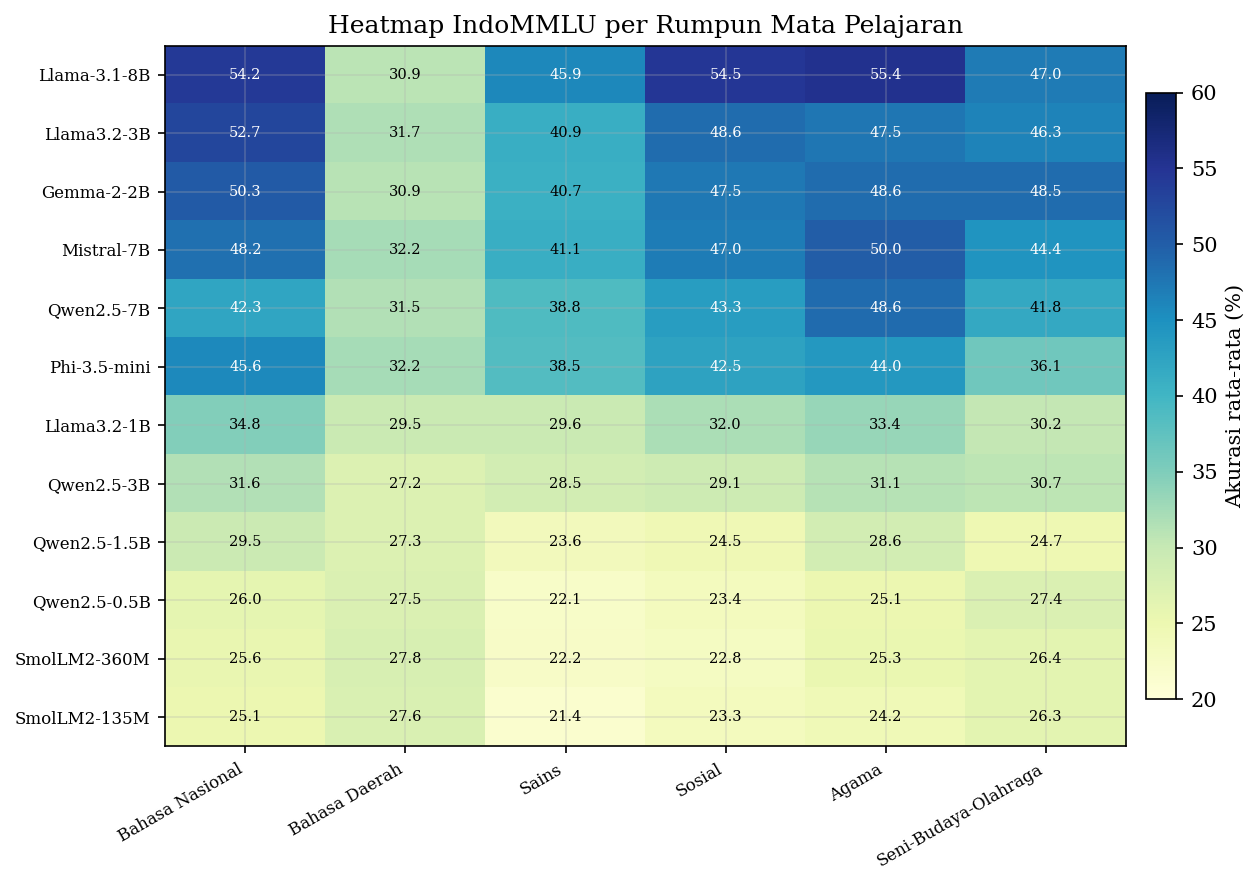

In [20]:
def fig18_rumpun_heatmap():
    g=_rumpun_matrix()
    fig,ax=plt.subplots(figsize=(8.5,6))
    im=ax.imshow(g.values,cmap="YlGnBu",vmin=20,vmax=60,aspect="auto")
    ax.set_xticks(range(g.shape[1])); ax.set_yticks(range(g.shape[0]))
    ax.set_xticklabels(g.columns,rotation=30,ha="right",fontsize=8); ax.set_yticklabels(g.index,fontsize=8)
    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            v=g.values[i,j]; ax.text(j,i,f"{v:.1f}",ha="center",va="center",fontsize=7,color="white" if v>42 else "black")
    cb=fig.colorbar(im,ax=ax,fraction=.03,pad=.02); cb.set_label("Akurasi rata-rata (%)")
    ax.set_title("Heatmap IndoMMLU per Rumpun Mata Pelajaran")
    plt.tight_layout(); plt.savefig("fig18_rumpun_heatmap.png", bbox_inches="tight"); plt.show()

fig18_rumpun_heatmap()

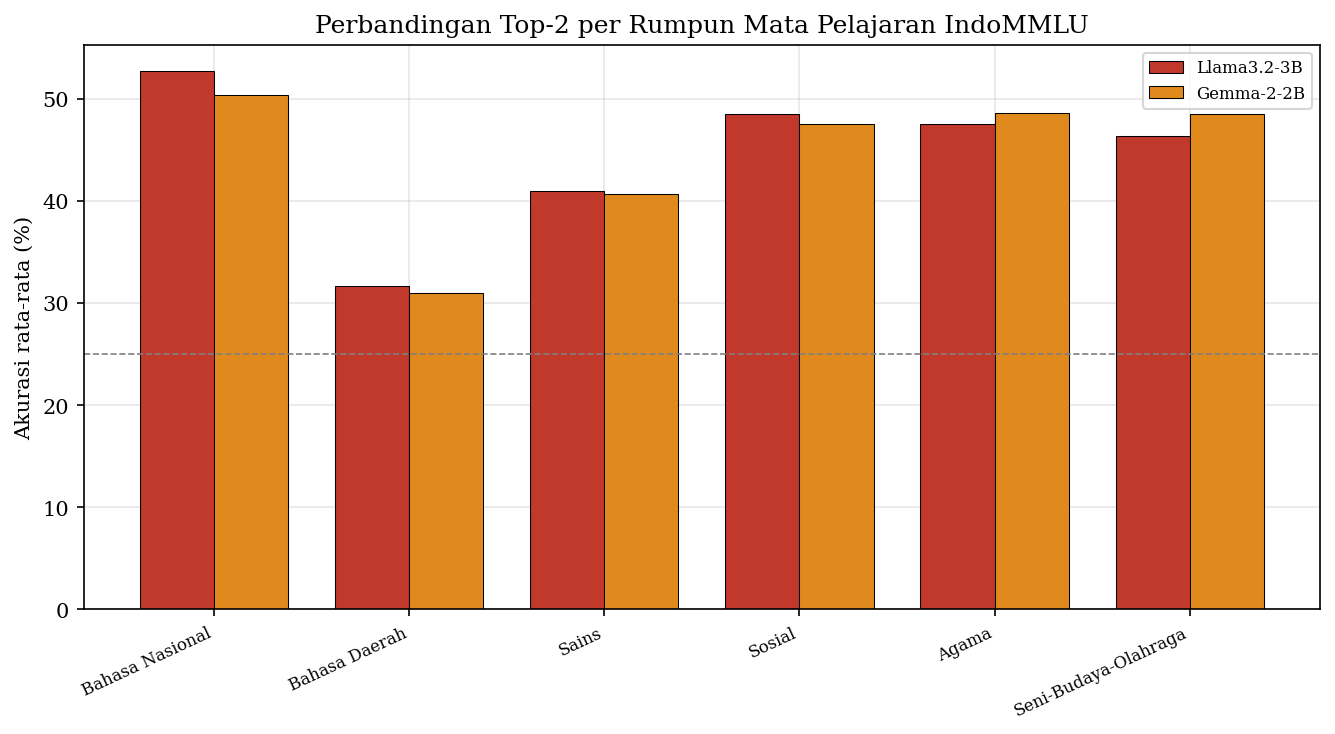

In [21]:
def fig19_rumpun_top2():
    g=_rumpun_matrix(); l=g.loc["Llama3.2-3B"]; gm=g.loc["Gemma-2-2B"]
    x=np.arange(len(g.columns)); w=.38
    fig,ax=plt.subplots(figsize=(9,5))
    ax.bar(x-w/2,l.values,w,label="Llama3.2-3B",color=C_TOP,edgecolor="black",linewidth=.5)
    ax.bar(x+w/2,gm.values,w,label="Gemma-2-2B",color=C_CAR,edgecolor="black",linewidth=.5)
    ax.set_xticks(x); ax.set_xticklabels(g.columns,rotation=25,ha="right",fontsize=8)
    ax.set_ylabel("Akurasi rata-rata (%)"); ax.axhline(25,ls="--",color="gray",lw=.8)
    ax.set_title("Perbandingan Top-2 per Rumpun Mata Pelajaran IndoMMLU"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig("fig19_rumpun_top2.png", bbox_inches="tight"); plt.show()

fig19_rumpun_top2()

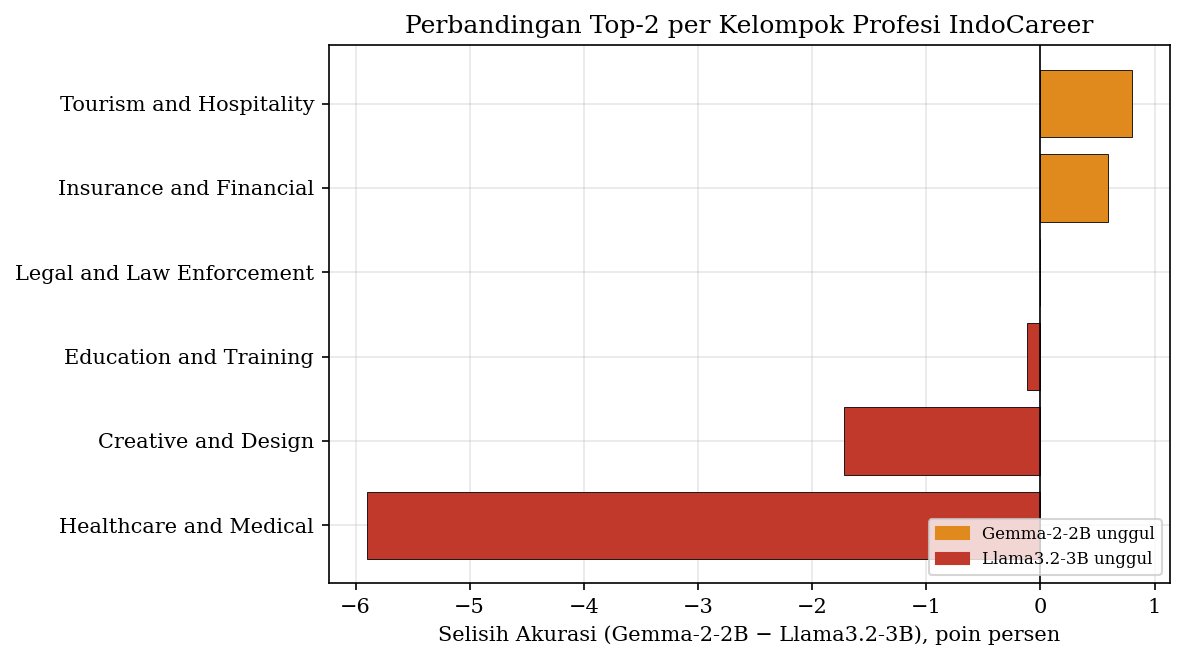

In [22]:
def fig20_career_top2():
    m=_career_matrix(); l=m.loc["Llama3.2-3B"]; g=m.loc["Gemma-2-2B"]
    diff=(g-l).sort_values(); labels=list(diff.index)
    colors=[C_CAR if v>0 else C_TOP for v in diff.values]
    fig,ax=plt.subplots(figsize=(8,4.5))
    ax.barh(labels,diff.values,color=colors,edgecolor="black",linewidth=.4)
    ax.axvline(0,color="black",lw=.8)
    ax.set_xlabel("Selisih Akurasi (Gemma-2-2B − Llama3.2-3B), poin persen")
    ax.set_title("Perbandingan Top-2 per Kelompok Profesi IndoCareer")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=C_CAR,label="Gemma-2-2B unggul"),Patch(color=C_TOP,label="Llama3.2-3B unggul")],fontsize=8,loc="lower right")
    plt.tight_layout(); plt.savefig("fig20_career_top2.png", bbox_inches="tight"); plt.show()

fig20_career_top2()

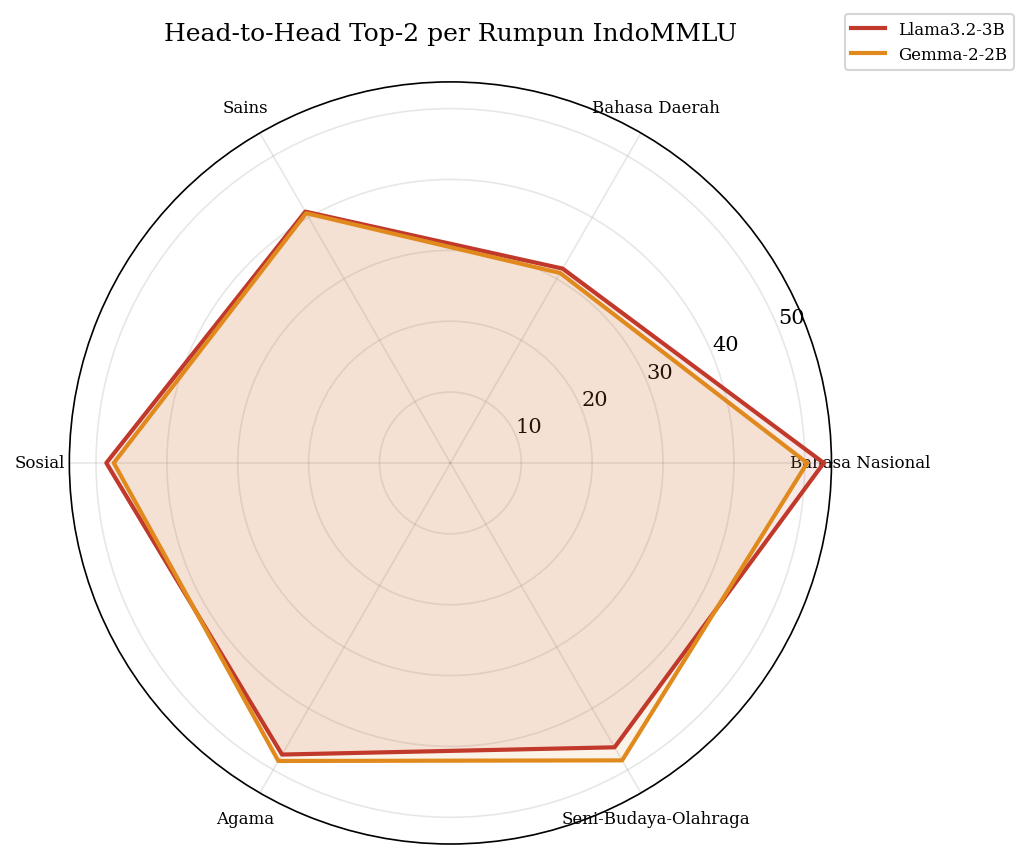

In [23]:
def fig21_head2head_radar():
    g=_rumpun_matrix(); cats=list(g.columns)
    ang=np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist(); ang+=ang[:1]
    fig,ax=plt.subplots(figsize=(7,7),subplot_kw=dict(polar=True))
    for m,col in [("Llama3.2-3B",C_TOP),("Gemma-2-2B",C_CAR)]:
        v=g.loc[m].tolist(); v+=v[:1]
        ax.plot(ang,v,color=col,lw=2,label=m); ax.fill(ang,v,color=col,alpha=.1)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(cats,fontsize=8)
    ax.set_title("Head-to-Head Top-2 per Rumpun IndoMMLU",pad=20)
    ax.legend(loc="upper right",bbox_to_anchor=(1.25,1.1),fontsize=8)
    plt.tight_layout(); plt.savefig("fig21_head2head_radar.png", bbox_inches="tight"); plt.show()

fig21_head2head_radar()

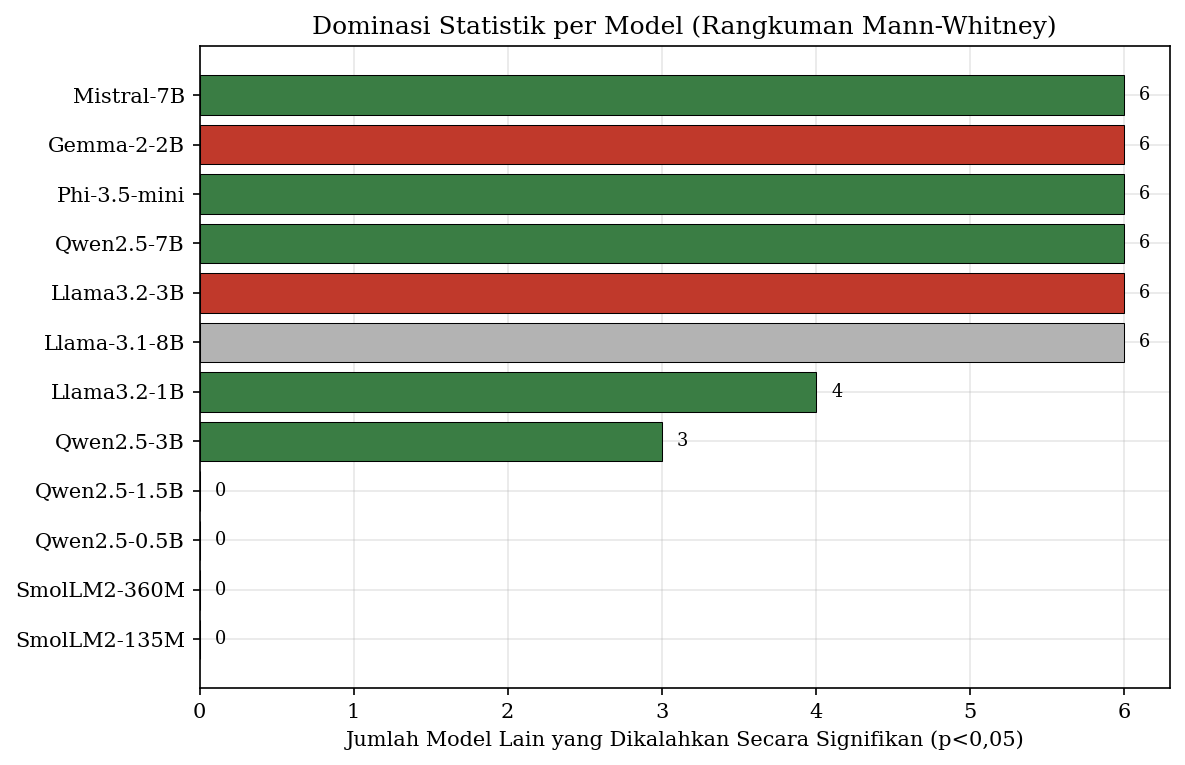

In [24]:
def fig22_mannwhitney_wincount():
    order=list(s.model_name); pv={(r["Model A"],r["Model B"]):(r["p-value"],r["Signifikan"]) for _,r in mw.iterrows()}
    win={m:0 for m in order}
    for a in order:
        for b in order:
            if a==b: continue
            rec=pv.get((a,b)) or pv.get((b,a))
            if rec and rec[1]=="Ya":
                sa=s[s.model_name==a].final_score_50_50.iloc[0]; sb=s[s.model_name==b].final_score_50_50.iloc[0]
                if sa>sb: win[a]+=1
    d=pd.Series(win).sort_values()
    colors=[C_TOP if m in ("Llama3.2-3B","Gemma-2-2B") else (C_DQ if not ELIG[m] else C_ELIG) for m in d.index]
    fig,ax=plt.subplots(figsize=(8,5.2))
    ax.barh(d.index,d.values,color=colors,edgecolor="black",linewidth=.5)
    for y,v in enumerate(d.values): ax.text(v+.1,y,str(int(v)),va="center",fontsize=8.5)
    ax.set_xlabel("Jumlah Model Lain yang Dikalahkan Secara Signifikan (p<0,05)")
    ax.set_title("Dominasi Statistik per Model (Rangkuman Mann-Whitney)")
    plt.tight_layout(); plt.savefig("fig22_mannwhitney_wincount.png", bbox_inches="tight"); plt.show()

fig22_mannwhitney_wincount()